Latest candidate file: /home/msp25gd/ResearchProjectMSc/HR/results/QuickSearch_V2/candidates_-3.5sig_1.5cut_2width_V2_resFirst_rerun_resFirst_rerun.npy
Input candidates: 498 | unique: 498
Dataset used for rerun: /home/msp25gd/Downloads/res/dataset/
Processed 25/498 | reconfirmed: 25 | missing: 0 | errors: 0
Processed 50/498 | reconfirmed: 50 | missing: 0 | errors: 0
Processed 75/498 | reconfirmed: 75 | missing: 0 | errors: 0
Processed 100/498 | reconfirmed: 100 | missing: 0 | errors: 0
Processed 125/498 | reconfirmed: 125 | missing: 0 | errors: 0
Processed 150/498 | reconfirmed: 150 | missing: 0 | errors: 0
Processed 175/498 | reconfirmed: 175 | missing: 0 | errors: 0
Processed 200/498 | reconfirmed: 200 | missing: 0 | errors: 0
Processed 225/498 | reconfirmed: 225 | missing: 0 | errors: 0
Processed 250/498 | reconfirmed: 250 | missing: 0 | errors: 0
Processed 275/498 | reconfirmed: 275 | missing: 0 | errors: 0
Processed 300/498 | reconfirmed: 300 | missing: 0 | errors: 0
Processed 325

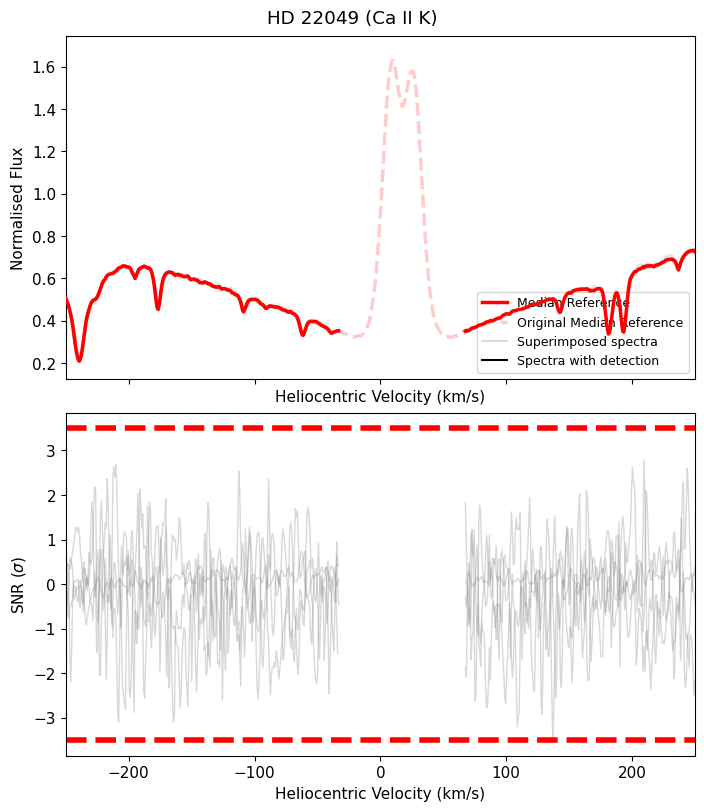

Saved: /home/msp25gd/ResearchProjectMSc/Images/finalStarImages/HD_22049_K.png
All stars have been looked at.
Saving progress...
Saved!


In [25]:
import pandas as pd
pd.set_option("display.max_rows", 50)

import numpy as np
import os, sys
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
plt.rcParams["font.size"] = "11"

# import multiprocessing
import json, argparse

%run ./asset.ipynb
%run ./otypes.ipynb
%run ./reduce_name.ipynb
%run ./match_name.ipynb
%run ./HR.ipynb
%run ./classifier.ipynb

# Set one star with starName, or provide a list in starNames for batch review.
#starName = 'bptau'
starNames = ['hd22049']
useSimbad = False

candidate_roots = [os.getcwd(), os.path.dirname(os.getcwd()), os.path.abspath(os.path.join(os.getcwd(), '..', '..'))]
project_root = next((root for root in candidate_roots if os.path.isdir(os.path.join(root, 'Images'))), candidate_roots[-1])
final_save_dir = os.path.join(project_root, 'Images', 'finalStarImages')
os.makedirs(final_save_dir, exist_ok=True)

sys.argv = [
    'iplotter.ipynb',
    '--idir', '../results/QuickSearch_V2/',
    '--r', '../results/CandidateReport_V2/',
    '--line', 'K'
 ]
if 'starName' in locals() and starName not in [None, '', 'None'] and len(starNames) == 0:
    sys.argv.extend(['--star', str(starName)])
print('Configured args:', sys.argv[1:])

parser = argparse.ArgumentParser(description='Automatic Spectroscopy Search for Exocomet Transits Tutorial', epilog='ASSET by RBW', allow_abbrev=False)
parser.add_argument('--p', metavar='param.json', default='param.json', help='parameter file name (default:input_param.json)')
parser.add_argument('--star', metavar='star', default='None', help='Individual star you want to look at')
parser.add_argument('--force', metavar='force_star', default='None', help='Force star you want to look at - input dataset name')
parser.add_argument('--nice', metavar='niceness', default=15, help='niceness of job (default: 15)')
parser.add_argument('--line', metavar='line', default='K', help='define what atomic line to use (default: "K")')
parser.add_argument('--cands', metavar='review_cands', default='False', help='review previously flagged as candidates (default: False)')
parser.add_argument('--r', metavar='res-path', default='../results/CandidateReport/', help='path for candidate report (default: CandidateReport/)')
parser.add_argument('--idir', metavar='input-path', default='../results/QuickSearch/', help='path for numpy list of candidates from quicksearch.py (default: QuickSearch/)')
parser.add_argument('--savefig', metavar='fig-path', default='None', help='path to save plots when running iplotter.py just for plots (default: None)')
args, _ = parser.parse_known_args()

os.nice(int(args.nice))

with open(args.p) as paramfile:
    param = json.load(paramfile)

# Force the pre-degradation dataset.
original_dataset = '/home/msp25gd/Downloads/res/dataset/'
if not os.path.isdir(original_dataset):
    raise FileNotFoundError(f'Pre-degradation dataset folder not found: {original_dataset}')
param['dataset'] = original_dataset
print('Using dataset:', param['dataset'])

instrument_label = 'UVES'

# Single-target display mode: do not auto-route or auto-save.
auto_route_plots = False
manual_multi_star_mode = isinstance(starNames, (list, tuple, np.ndarray)) and len(starNames) > 0
if (not manual_multi_star_mode) and str(args.star) == 'None' and str(args.force) == 'None':
    raise ValueError('Provide --star <name> or --force <reduced_name> to plot a single target.')

if manual_multi_star_mode:
    candidates = []
    for raw_star in starNames:
        target = to_reduce(str(raw_star))
        try:
            cand_info = find_target(target)
            cand_red = str(cand_info.Reduced)
            display_name = str(cand_info.Sanitised)
        except (FileNotFoundError, KeyError):
            metadata = pd.read_pickle('/home/msp25gd/Downloads/res/meta/metadata.pkl')
            reduced_col = 'Reduced' if 'Reduced' in metadata.columns else 'reduced'
            sanitised_col = 'Sanitised' if 'Sanitised' in metadata.columns else ('sanitised' if 'sanitised' in metadata.columns else None)
            match = metadata[metadata[reduced_col].astype(str).str.lower() == str(target).lower()]
            if len(match) == 0:
                print('Skipping {} ({}): not found.'.format(str(raw_star), target))
                continue
            row = match.iloc[0]
            cand_red = str(row[reduced_col])
            display_name = str(row[sanitised_col]) if sanitised_col is not None else cand_red
        candidates.append(cand_red)
        print('Queued star {} ({})'.format(display_name, cand_red))
    candidates = list(dict.fromkeys(candidates))
    if len(candidates) == 0:
        raise ValueError('No valid stars found in starNames.')
    single_star = False
elif str(args.star) != 'None':
    target = to_reduce(str(args.star))
    try:
        cand_info = find_target(target)
        candidates = [cand_info.Reduced]
        print('The star {} is observed by UVES.'.format(cand_info.Sanitised))
        single_star = True
    except (FileNotFoundError, KeyError):
        # Fallback for metadata schemas without the 'New Groups' column.
        metadata = pd.read_pickle('/home/msp25gd/Downloads/res/meta/metadata.pkl')
        reduced_col = 'Reduced' if 'Reduced' in metadata.columns else 'reduced'
        sanitised_col = 'Sanitised' if 'Sanitised' in metadata.columns else ('sanitised' if 'sanitised' in metadata.columns else None)
        match = metadata[metadata[reduced_col].astype(str).str.lower() == str(target).lower()]
        if len(match) == 0:
            print('The star {} ({}) does not exist. Try again!'.format(str(args.star), target))
            sys.exit()
        row = match.iloc[0]
        candidates = [str(row[reduced_col])]
        display_name = str(row[sanitised_col]) if sanitised_col is not None else candidates[0]
        print('The star {} is observed by UVES.'.format(display_name))
        single_star = True
elif str(args.force) != 'None':
    candidates = [str(args.force)]
    single_star = True
else:
    raise RuntimeError('Single-target mode requires --star or --force.')

# old_report = pd.read_pickle('CandidateReport/old_candidate_report.pkl')
# newest_report = pd.read_pickle('CandidateReport2/candidate_report.pkl')

if not os.path.exists(args.r):
    os.makedirs(args.r)
    print("new directory {} created!".format(args.r))

Search = ASSET(parameters = param, line=args.line)
Classifier = Classify(param, args.r)

review_flagged = True

while review_flagged == True:
    look_flagged = None # Flag to note if user wants to review flagged targets
    review_skipped = True

    while review_skipped == True:

        look_skip = None # Flag to note if user wants to review skipped targets
        
        for i,cand in enumerate(candidates):

            plot = False
            Search.ccf = False

            classified = Classifier.candidate_info(cand)
            Classifier.current_status = None
            
            if classified:
                if str(args.savefig) != 'None':
                    print('This star: {} has been classified as {}.'.format(cand, Classifier.previous_report.Status.to_numpy()[0]))

                elif Classifier.flagged:
                    print('This star: {} has already been flagged.'.format(cand))
                elif (single_star == True) or manual_multi_star_mode:
                    print('This star: {} has already been classified as {}.'.format(cand, Classifier.previous_report.Status.to_numpy()[0]))
                else:
                    continue
            print('{}:----------------{}/{}--------------------'.format(cand,i+1, len(candidates)))

            star_path = param["dataset"] + '{}/'.format(cand)
            spec_param = Search.spec_analysis(star_path)

            if spec_param == None:
                if single_star == True:
                    print('{}: Not enough spectra for the search to be completed.'.format(cand))
                    sys.exit()
                else:
                    continue
            else:
                new_spectra, med, med_err = spec_param
                ref_spec = med[Search.snr_idxrange]

                corr_med = med.copy()
                if Search.ccf == True:
                    rv_shift = Search.X_corr(corr_med)
                    cond100 = (Search.radial_velocity > rv_shift-50) & (Search.radial_velocity < rv_shift+50)
                    corr_med[cond100] = np.nan

                Classifier.target_info = Search.df            

            while Classifier.current_status == None:

                fig, (ax2, ax3) = plt.subplots(2, 1, figsize=(1040 / 150, 8), sharex=True, constrained_layout=True)

                fig.suptitle(f"{Search.target_san} (Ca II {args.line})")

                ax2.set_ylabel('Normalised Flux')
                ax2.set_xlabel('Heliocentric Velocity (km/s)')
                ax2.set_xlim(Search.rv_min,Search.rv_max)

                ax3.set_ylabel('SNR ($\\sigma$)')
                ax3.set_xlabel('Heliocentric Velocity (km/s)')
                ax3.hlines(-1 * Search.threshold, Search.rv_min,Search.rv_max, linestyles= 'dashed', linewidth=4, colors='red')
                ax3.hlines(1 * Search.threshold, Search.rv_min,Search.rv_max, linestyles= 'dashed', linewidth=4, colors='red')

                indices = []
                all_min_SNR = []
                all_rv_pos = []
                all_width = []
                all_abs_depth = []
                all_max_peak = []

                for i in range(len(new_spectra)):

                    detection = False

                    spec = new_spectra[i]

                    corr_spec = spec.copy()
                    if Search.ccf:
                        corr_spec[cond100] = np.nan

                    filtered_spec = spec[Search.snr_idxrange]
                    snr = Search.snr(spec, med, Search.spectra_err[i], med_err)
                        
                    sd = np.std(snr)

                    corr_snr = snr.copy()
                    if Search.ccf == True:
                        corr_snr[cond100] = np.nan

                    corr_snr = corr_snr[Search.snr_idxrange]

                    sig = corr_snr/sd

                    min_detect = np.nanmin(sig)
                    max_detect = np.nanmax(sig)
                    all_min_SNR.append(round(min_detect,2))
                    all_max_peak.append(round(max_detect,2))

                    filtered_rv = Search.radial_velocity[Search.snr_idxrange]
                    rv_detect = filtered_rv[sig == min_detect][0]
                    all_rv_pos.append(round(rv_detect,2))

                    if min_detect < Search.threshold:
                        width = Search.get_width(sig)
                        if width >= Search.width_filter:
                            plot = True
                            detection = True

                            indices.append(i)
                            all_width.append(width)

                            abs_depth = (ref_spec[filtered_rv == rv_detect] - filtered_spec[filtered_rv == rv_detect])/ref_spec[filtered_rv == rv_detect]
                            all_abs_depth.append(round(abs_depth[0],2))

                            ax2.plot(Search.radial_velocity, corr_spec, linewidth = 2,alpha = 0.7, color ='k', zorder= 5)
                            ax3.plot(filtered_rv, sig, linewidth =1.5,color = 'k', alpha= 0.5, zorder = 5)


                    if detection == False:
                        ax2.plot(Search.radial_velocity, corr_spec, linewidth = 2,alpha = 0.2, color ='grey', zorder = 0)
                        ax3.plot(filtered_rv, sig, linewidth =1,color = 'grey', alpha= 0.3, zorder = 0)
    
                ax2.plot(Search.radial_velocity, corr_med, linewidth = 2.5,color = 'r', label='Median Reference', zorder = 10)
                if Search.ccf:
                    ax2.plot(Search.radial_velocity, med, linewidth = 2.5,color = 'r', linestyle = '--', alpha =0.2, label='Original Median Reference', zorder = 0)
                
                handles, labels = ax2.get_legend_handles_labels()
                spectra_legend = Line2D([0], [0], label='Superimposed spectra', color='g', alpha=0.2)
                spectra_det_legend = Line2D([0], [0], label='Spectra with detection', color='k')
                handles.extend([spectra_legend, spectra_det_legend])
                ax2.legend(handles=handles, loc='lower right', fontsize=9)

                Classifier.target_info['Min_SNR'] = all_min_SNR
                Classifier.target_info['Max_Peak_SNR'] = all_max_peak
                Classifier.target_info['RV_pos'] = all_rv_pos
                Classifier.detection_info = Classifier.target_info.iloc[indices].copy()
                Classifier.detection_info['Abs_width'] = all_width
                Classifier.detection_info['Abs_depth'] = all_abs_depth

                if plot == True:

                    if str(args.savefig) != 'None':
                        plt.savefig(args.savefig + '{}.png'.format(cand), bbox_inches = 'tight', dpi=150)
                        print(cand, 'saved!')
                        Classifier.current_status = 'saved'
                        plt.close(fig)
                        continue

                    if auto_route_plots:
                        Classifier.auto_route(True, Search.rv_min, Search.rv_max, Search.threshold, Search.width_filter, peak_threshold=abs(float(Search.threshold)))
                    else:
                        plt.show(block=False)
                        if single_star or manual_multi_star_mode:
                            Classifier.current_status = 'plotted'
                        else:
                            Classifier.ask_user()

                else:
                    if auto_route_plots:
                        Classifier.auto_route(False, Search.rv_min, Search.rv_max, Search.threshold, Search.width_filter, peak_threshold=abs(float(Search.threshold)))
                    elif single_star == True or manual_multi_star_mode:
                        print('{}: No detection for this star.'.format(cand))
                        plt.show(block=False)
                        Classifier.current_status = 'plotted'
                    else:
                        plt.close(fig)
                        Classifier.current_status = 'skipped'

                if manual_multi_star_mode:
                    safe_name = ''.join(ch if ch.isalnum() or ch in '._-' else '_' for ch in str(Search.target_san))
                    save_out = os.path.join(final_save_dir, '{}_{}.png'.format(safe_name, str(args.line).upper()))
                    fig.savefig(save_out, bbox_inches='tight', dpi=150)
                    print('Saved:', save_out)
                    plt.close(fig)

            if single_star == True and (not manual_multi_star_mode) and auto_route_plots == False:
                review_skipped = False
                review_flagged = False
                break
                
            if manual_multi_star_mode:
                continue

            if str(args.savefig) != 'None':
                continue

            save_path = Classifier.classify()

            if save_path != None:
                print('{}: Saving fig...'.format(Search.target_red))
                fig.savefig(save_path + '{}.png'.format(Search.target_red), dpi=150)
                print('{}: Saved fig!'.format(Search.target_red))
            
            plt.close(fig)

        if str(args.savefig) != 'None':
            sys.exit()

        if auto_route_plots:
            review_skipped = False
            continue

        if manual_multi_star_mode:
            review_skipped = False
        elif single_star == True and auto_route_plots == False:
            review_skipped = False
        elif len(Classifier.skipped) >= 1:
            while (look_skip != 'y') & (look_skip != 'n'):
                look_skip = input('Do you want to review Skipped targets? (y/n) ')
                if look_skip == 'y':
                    review_skipped = True
                    candidates = Classifier.skipped
                    Classifier.skipped = []
                elif look_skip == 'n':
                    review_skipped = False
                    Classifier.skipped = []
                else:
                    print('Answer not recorded. Try again.')
        else:
            review_skipped = False

    if auto_route_plots:
        review_flagged = False
        continue

    # If there are any flagged targets
    if manual_multi_star_mode:
        review_flagged = False
    elif single_star == True and auto_route_plots == False:
        review_flagged = False
    elif len(Classifier.candidate_report.Target[Classifier.candidate_report.Status == 'flagged'].to_numpy()) >= 1:
        while (look_flagged != 'y') & (look_flagged != 'n'):
            look_flagged = input('Do you want to review Flagged targets? (y/n) ')
            if look_flagged == 'y':
                review_flagged = True
                candidates = Classifier.candidate_report.Target[Classifier.candidate_report.Status == 'flagged'].to_numpy()
            elif look_flagged == 'n':
                review_flagged = False
            else:
                print('Answer not recorded. Try again.')
    else:
        review_flagged = False

print('All stars have been looked at.')
print('Saving progress...')
Classifier.candidate_report.to_pickle(Classifier.cand_report_path)
Classifier.candidate_report.to_html(Classifier.res_path + 'Report.html')
print('Saved!')

In [20]:
from pathlib import Path
import shutil
import numpy as np
import pandas as pd

# Merge the duplicate Beta Pic groups into a single processed group called hd39060.
# No extra regridding is needed here because both folders already share the same
# processed wavelength/RV grids; spec_analysis() will rebuild the common reference
# spectrum and redo the normalisation/noise filtering when you plot hd39060 later.

dataset_root = Path('/home/msp25gd/Downloads/res/dataset')
source_groups = ['betpic', 'hd39060']
target_name = 'hd39060'
backup_name = f'{target_name}_premerge_backup'

def merge_processed_groups(source_groups, target_name, dataset_root):
    source_paths = [dataset_root / name for name in source_groups]
    target_path = dataset_root / target_name
    backup_path = dataset_root / backup_name
    temp_path = dataset_root / f'{target_name}__merge_tmp'

    bundles = []
    for path in source_paths:
        if not path.exists():
            raise FileNotFoundError(f'Missing dataset group: {path}')

        meta = pd.read_pickle(path / 'meta' / 'group_df.pkl').copy()
        fits = np.load(path / 'meta' / 'fits.npy', allow_pickle=True)
        sK = np.load(path / 'spec' / 'sK.npy')
        sH = np.load(path / 'spec' / 'sH.npy')
        rvK = np.load(path / 'wavelength' / 'rvK.npy')
        rvH = np.load(path / 'wavelength' / 'rvH.npy')
        wK = np.load(path / 'wavelength' / 'wK.npy')
        wH = np.load(path / 'wavelength' / 'wH.npy')

        if not (len(meta) == len(fits) == sK.shape[0] == sH.shape[0]):
            raise ValueError(f'Row mismatch inside {path.name}: meta={len(meta)}, fits={len(fits)}, sK={sK.shape[0]}, sH={sH.shape[0]}')

        bundles.append(
            {
                'name': path.name,
                'meta': meta,
                'fits': fits,
                'sK': sK,
                'sH': sH,
                'rvK': rvK,
                'rvH': rvH,
                'wK': wK,
                'wH': wH,
            }
        )

    reference = bundles[0]
    for bundle in bundles[1:]:
        if not np.array_equal(reference['rvK'], bundle['rvK']):
            raise ValueError(f"rvK grid mismatch between {reference['name']} and {bundle['name']}")
        if not np.array_equal(reference['rvH'], bundle['rvH']):
            raise ValueError(f"rvH grid mismatch between {reference['name']} and {bundle['name']}")
        if not np.array_equal(reference['wK'], bundle['wK']):
            raise ValueError(f"wK grid mismatch between {reference['name']} and {bundle['name']}")
        if not np.array_equal(reference['wH'], bundle['wH']):
            raise ValueError(f"wH grid mismatch between {reference['name']} and {bundle['name']}")

    combined_meta = pd.concat([bundle['meta'] for bundle in bundles], ignore_index=True)
    combined_fits = np.concatenate([bundle['fits'] for bundle in bundles])
    combined_sK = np.vstack([bundle['sK'] for bundle in bundles])
    combined_sH = np.vstack([bundle['sH'] for bundle in bundles])

    # Drop any repeated FITS entries so rerunning the cell stays idempotent.
    fit_keys = pd.Series(combined_fits.astype(str))
    keep_mask = ~fit_keys.duplicated()
    combined_meta = combined_meta.loc[keep_mask].reset_index(drop=True)
    combined_fits = combined_fits[keep_mask.to_numpy()]
    combined_sK = combined_sK[keep_mask.to_numpy()]
    combined_sH = combined_sH[keep_mask.to_numpy()]

    # Prefer chronological ordering when timing metadata is available.
    sort_column = None
    for candidate in ['MJD-OBS', 'Date']:
        if candidate in combined_meta.columns:
            sort_column = candidate
            break

    if sort_column is not None:
        sort_values = pd.to_numeric(combined_meta[sort_column], errors='coerce')
        if sort_values.notna().any():
            sort_index = np.argsort(np.where(sort_values.notna(), sort_values, np.inf))
            combined_meta = combined_meta.iloc[sort_index].reset_index(drop=True)
            combined_fits = combined_fits[sort_index]
            combined_sK = combined_sK[sort_index]
            combined_sH = combined_sH[sort_index]

    # Make the merged target present itself consistently as hd39060.
    if 'Reduced' in combined_meta.columns:
        combined_meta['Reduced'] = target_name
    if 'Sanitised' in combined_meta.columns:
        combined_meta['Sanitised'] = target_name

    if target_path.exists() and not backup_path.exists():
        shutil.copytree(target_path, backup_path)
        print(f'Backup created: {backup_path}')

    if temp_path.exists():
        shutil.rmtree(temp_path)

    (temp_path / 'meta').mkdir(parents=True, exist_ok=True)
    (temp_path / 'spec').mkdir(parents=True, exist_ok=True)
    (temp_path / 'wavelength').mkdir(parents=True, exist_ok=True)

    combined_meta.to_pickle(temp_path / 'meta' / 'group_df.pkl')
    np.save(temp_path / 'meta' / 'fits.npy', combined_fits)
    np.save(temp_path / 'spec' / 'sK.npy', combined_sK)
    np.save(temp_path / 'spec' / 'sH.npy', combined_sH)
    np.save(temp_path / 'wavelength' / 'rvK.npy', reference['rvK'])
    np.save(temp_path / 'wavelength' / 'rvH.npy', reference['rvH'])
    np.save(temp_path / 'wavelength' / 'wK.npy', reference['wK'])
    np.save(temp_path / 'wavelength' / 'wH.npy', reference['wH'])

    if target_path.exists():
        shutil.rmtree(target_path)
    temp_path.rename(target_path)

    print(f'Merged groups: {source_groups} -> {target_path.name}')
    print(f'Total spectra in merged group: {len(combined_meta)}')
    print(f'Unique FITS files kept: {len(combined_fits)}')
    return combined_meta

merged_hd39060_df = merge_processed_groups(source_groups, target_name, dataset_root)
preview_cols = [col for col in ['OBJECT', 'Object', 'Sanitised', 'Reduced', 'MJD-OBS', 'Date'] if col in merged_hd39060_df.columns]
display(merged_hd39060_df[preview_cols].head())

Merged groups: ['betpic', 'hd39060'] -> hd39060
Total spectra in merged group: 42
Unique FITS files kept: 42


,OBJECT,Sanitised,Reduced,MJD-OBS
0,HD-39060,hd39060,hd39060,52244.286535
1,HD-39060,hd39060,hd39060,52245.151218
2,HD-39060,hd39060,hd39060,52245.230178
3,HD-39060,hd39060,hd39060,52245.270736
4,HD-39060,hd39060,hd39060,52277.264645


In [26]:
import pandas as pd
pd.set_option("display.max_rows", 50)

import numpy as np
import os, sys
import json
import argparse
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
plt.rcParams["font.size"] = "11"

from IPython import get_ipython


def _ensure_runtime_state():
    """Load the helper notebooks and parameter file when the main setup cell was not run."""
    global param

    if 'param' not in globals():
        parser = argparse.ArgumentParser(description='Automatic Spectroscopy Search for Exocomet Transits Tutorial', epilog='ASSET by RBW', allow_abbrev=False)
        parser.add_argument('--p', metavar='param.json', default='param.json', help='parameter file name (default:input_param.json)')
        parser.add_argument('--star', metavar='star', default='None', help='Individual star you want to look at')
        parser.add_argument('--force', metavar='force_star', default='None', help='Force star you want to look at - input dataset name')
        parser.add_argument('--line', metavar='line', default='K', help='define what atomic line to use (default: "K")')
        args, _ = parser.parse_known_args()

        param_path = args.p
        if not os.path.exists(param_path):
            param_path = os.path.join(os.getcwd(), param_path)
        if not os.path.exists(param_path):
            notebook_dir = os.path.abspath('HR/search') if os.path.exists('HR/search/iplotter.ipynb') else os.getcwd()
            param_path = os.path.join(notebook_dir, 'param.json')
        if os.path.exists(param_path):
            with open(param_path) as paramfile:
                param = json.load(paramfile)
        else:
            raise FileNotFoundError('Could not find param.json for the helper.')

    original_dataset = '/home/msp25gd/Downloads/res/dataset/'
    if not os.path.isdir(original_dataset):
        raise FileNotFoundError(f'Pre-degradation dataset folder not found: {original_dataset}')
    if param.get('dataset') != original_dataset:
        print('Overriding dataset to pre-degradation set:', original_dataset)
    param['dataset'] = original_dataset

    notebook_dir = os.path.abspath('HR/search') if os.path.exists('HR/search/iplotter.ipynb') else os.getcwd()
    for notebook_name, required_name in [
        ('asset.ipynb', 'ASSET'),
        ('otypes.ipynb', 'get_otypes'),
        ('reduce_name.ipynb', 'to_reduce'),
        ('match_name.ipynb', 'find_target'),
        ('HR.ipynb', 'HR'),
        ('classifier.ipynb', 'Classifier'),
    ]:
        if required_name not in globals():
            notebook_path = os.path.join(notebook_dir, notebook_name)
            if os.path.exists(notebook_path):
                try:
                    get_ipython().run_line_magic('run', notebook_path)
                except Exception:
                    pass

    return param


_ensure_runtime_state()


def _get_save_dir():
    for candidate_root in [os.getcwd(), os.path.dirname(os.getcwd()), os.path.abspath(os.path.join(os.getcwd(), '..', '..'))]:
        if os.path.isdir(os.path.join(candidate_root, 'Images')):
            return os.path.join(candidate_root, 'Images', 'finalStarImages')
    return os.path.join(os.getcwd(), 'Images', 'finalStarImages')


def plot_single_star_iplotter(star_names, line='K', save_path=None, show=True, prompt_save=False):
    """Plot one or more stars sequentially and keep the figure compact."""
    _ensure_runtime_state()

    if isinstance(star_names, str):
        star_names = [star_names]
    else:
        star_names = list(star_names)

    save_dir = _get_save_dir()
    os.makedirs(save_dir, exist_ok=True)

    def _resolve_target_row(star_name):
        reduced_name = str(star_name)
        if 'to_reduce' in globals():
            try:
                reduced_name = to_reduce(str(star_name))
            except Exception:
                pass

        candidate_paths = [
            '/home/msp25gd/Downloads/res/meta/metadata.pkl',
            os.path.join(os.getcwd(), 'metadata.pkl'),
            os.path.join(os.getcwd(), 'res', 'meta', 'metadata.pkl'),
        ]
        for metadata_path in candidate_paths:
            if os.path.exists(metadata_path):
                metadata = pd.read_pickle(metadata_path)
                break
        else:
            raise FileNotFoundError('Could not find the metadata pickle for the target helper.')

        reduced_key = None
        for candidate in ['Reduced', 'reduced']:
            if candidate in metadata.columns:
                reduced_key = candidate
                break

        if reduced_key is None:
            raise KeyError('The metadata pickle does not contain a Reduced column.')

        matches = metadata[metadata[reduced_key].astype(str).str.lower() == reduced_name.lower()]
        if len(matches) == 0:
            raise FileNotFoundError(f'Could not find a metadata row for {reduced_name}.')
        return matches.iloc[0]

    for idx, star_name in enumerate(star_names, 1):
        print(f'[{idx}/{len(star_names)}] {star_name}')
        cand_info = _resolve_target_row(star_name)

        star_red = str(cand_info.get('Reduced', cand_info.get('reduced', str(star_name))))
        star_san = str(cand_info.get('Sanitised', cand_info.get('sanitised', star_red)))
        star_harps = cand_info.get('HARPS', cand_info.get('Harps', cand_info.get('HARP', None)))
        if star_harps is None:
            star_harps = star_red

        Search = ASSET(parameters=param, line=line)
        Search.ccf = False
        Search.target_san = star_san
        Search.target_red = star_red
        Search.target_harps = star_harps

        star_path = param['dataset'] + '{}/'.format(star_red)
        spec_param = Search.spec_analysis(star_path)
        if spec_param is None:
            raise ValueError(f'Not enough spectra for {star_red}.')

        new_spectra, med, med_err = spec_param
        corr_med = med.copy()
        rv_mask = None
        if Search.ccf:
            rv_shift = Search.X_corr(corr_med)
            rv_mask = (Search.radial_velocity > rv_shift - 50) & (Search.radial_velocity < rv_shift + 50)
            corr_med[rv_mask] = np.nan

        fig, (ax2, ax3) = plt.subplots(2, 1, figsize=(1040 / 150, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
        title_label = 'CaII K' if line.upper() == 'K' else line
        fig.suptitle(f"{star_san} ({title_label})")

        ax2.set_ylabel('Normalised Flux')
        ax2.set_xlim(Search.rv_min, Search.rv_max)

        ax3.set_ylabel('SNR ($\\sigma$)')
        ax3.set_xlabel('Heliocentric Velocity (km/s)')
        ax3.hlines(-1 * Search.threshold, Search.rv_min, Search.rv_max, linestyles='dashed', linewidth=3, colors='red')
        ax3.hlines(1 * Search.threshold, Search.rv_min, Search.rv_max, linestyles='dashed', linewidth=3, colors='red')

        epoch_rows = []
        for epoch_idx, spec in enumerate(new_spectra):
            snr = Search.snr(spec, med, Search.spectra_err[epoch_idx], med_err)
            sd = np.std(snr)
            corr_snr = snr.copy()[Search.snr_idxrange]
            filtered_rv = Search.radial_velocity[Search.snr_idxrange]

            if Search.ccf and rv_mask is not None:
                corr_snr[rv_mask[Search.snr_idxrange]] = np.nan

            sig = corr_snr / sd
            min_detect = float(np.nanmin(sig))
            rv_detect = float(filtered_rv[np.nanargmin(sig)])

            corr_spec = spec.copy()
            if Search.ccf and rv_mask is not None:
                corr_spec[rv_mask] = np.nan

            width = float(Search.get_width(sig)) if np.isfinite(sig).any() else 0.0
            is_strict = (min_detect < Search.threshold) and (width >= Search.width_filter)

            epoch_rows.append(
                {
                    'corr_spec': corr_spec,
                    'filtered_rv': filtered_rv,
                    'sig': sig,
                    'min_detect': min_detect,
                    'rv_detect': rv_detect,
                    'width': width,
                    'is_strict': is_strict,
                }
            )

        strict_count = sum(1 for row in epoch_rows if row['is_strict'])
        edge_overlay_idx = None

        if strict_count == 0:
            edge_window = 25.0
            edge_rows = [
                (i, row) for i, row in enumerate(epoch_rows)
                if (abs(row['rv_detect'] - Search.rv_min) <= edge_window) or (abs(row['rv_detect'] - Search.rv_max) <= edge_window)
            ]
            near_threshold_rows = [
                (i, row) for i, row in edge_rows
                if row['min_detect'] <= (Search.threshold + 0.2)
            ]
            if near_threshold_rows:
                edge_overlay_idx = min(near_threshold_rows, key=lambda x: x[1]['min_detect'])[0]
                row = epoch_rows[edge_overlay_idx]
                print(
                    f"{star_red}: no strict detections (width >= {Search.width_filter}); "
                    f"overlaying edge-of-window review epoch at RV {row['rv_detect']:.1f} km/s (min sigma {row['min_detect']:.2f}, width {row['width']:.2f})."
                )

        for epoch_idx, row in enumerate(epoch_rows):
            draw_as_detection = row['is_strict'] or (edge_overlay_idx is not None and epoch_idx == edge_overlay_idx)
            if draw_as_detection:
                ax2.plot(Search.radial_velocity, row['corr_spec'], linewidth=2, alpha=0.7, color='k', zorder=5)
                ax3.plot(row['filtered_rv'], row['sig'], linewidth=1.5, color='k', alpha=0.5, zorder=5)
            else:
                ax2.plot(Search.radial_velocity, row['corr_spec'], linewidth=2, alpha=0.2, color='grey', zorder=0)
                ax3.plot(row['filtered_rv'], row['sig'], linewidth=1, color='grey', alpha=0.3, zorder=0)

        ax2.plot(Search.radial_velocity, corr_med, linewidth=2.5, color='r', label='Median Reference', zorder=10)
        if Search.ccf:
            ax2.plot(Search.radial_velocity, med, linewidth=2.5, color='r', linestyle='--', alpha=0.2, label='Original Median Reference', zorder=0)

        handles, labels = ax2.get_legend_handles_labels()
        spectra_legend = Line2D([0], [0], label='Superimposed spectra', color='g', alpha=0.2)
        spectra_det_legend = Line2D([0], [0], label='Spectra with detection', color='k')
        handles.extend([spectra_legend, spectra_det_legend])
        ax2.legend(handles=handles, loc='upper right', fontsize=9)

        if show:
            plt.show()

        safe_name = ''.join(ch if ch.isalnum() or ch in '._-' else '_' for ch in str(star_san))
        target_path = save_path if save_path is not None else os.path.join(save_dir, f'{safe_name}_{line.upper()}.png')
        fig.savefig(target_path, dpi=150)
        print(f'Saved figure to {target_path}')

        plt.close(fig)

    return None


# Example usage:
# plot_single_star_iplotter(['hd22049', 'betapic'])

[1/2] hr1996


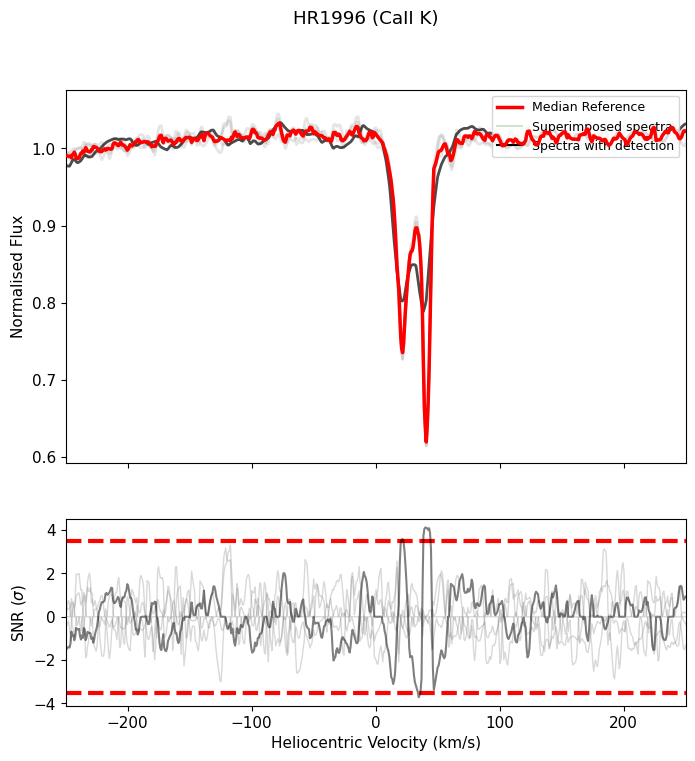

Saved figure to /home/msp25gd/ResearchProjectMSc/Images/starExamples/HR1996_K.png
[2/2] hd27679


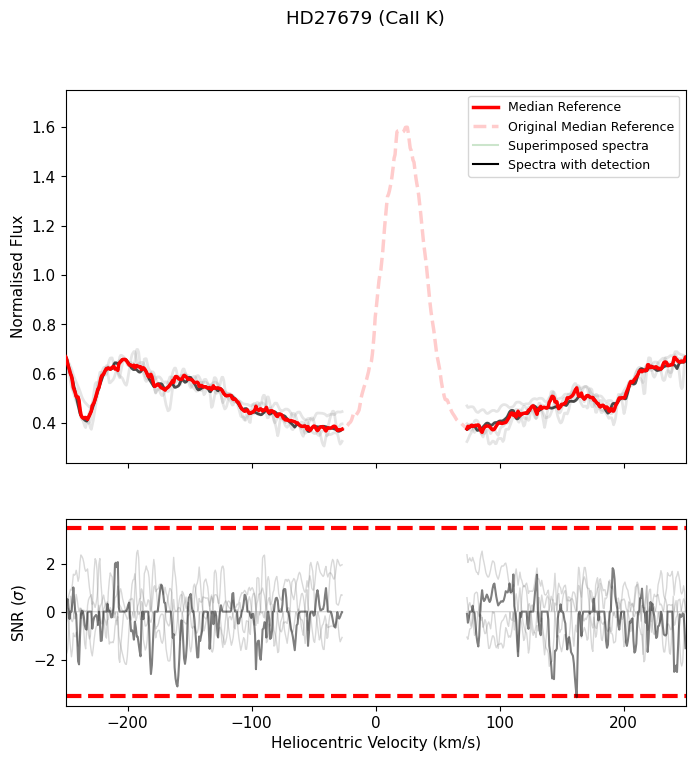

Saved figure to /home/msp25gd/ResearchProjectMSc/Images/starExamples/HD27679_K.png


In [41]:
plot_single_star_iplotter(['hr1996', 'hd27679'])


cd-2417504 - K line summary
 epoch  min_sigma  max_sigma  rv_at_min  width  abs_depth
     1      -3.71       3.45    -123.99      7      0.206
     2      -3.36       3.43    -123.99      0      0.201
     3      -3.50       3.45     111.02      2      0.105
     4      -3.13       2.85     207.93      0      0.032
     5      -2.98       3.25     193.43      0      0.032
     6      -2.66       2.52    -185.03      0      0.041
     7      -3.08       2.77      11.83      0      0.042
Threshold dip present: True
Peak above +threshold present: False
Dip repeated in multiple epochs: False


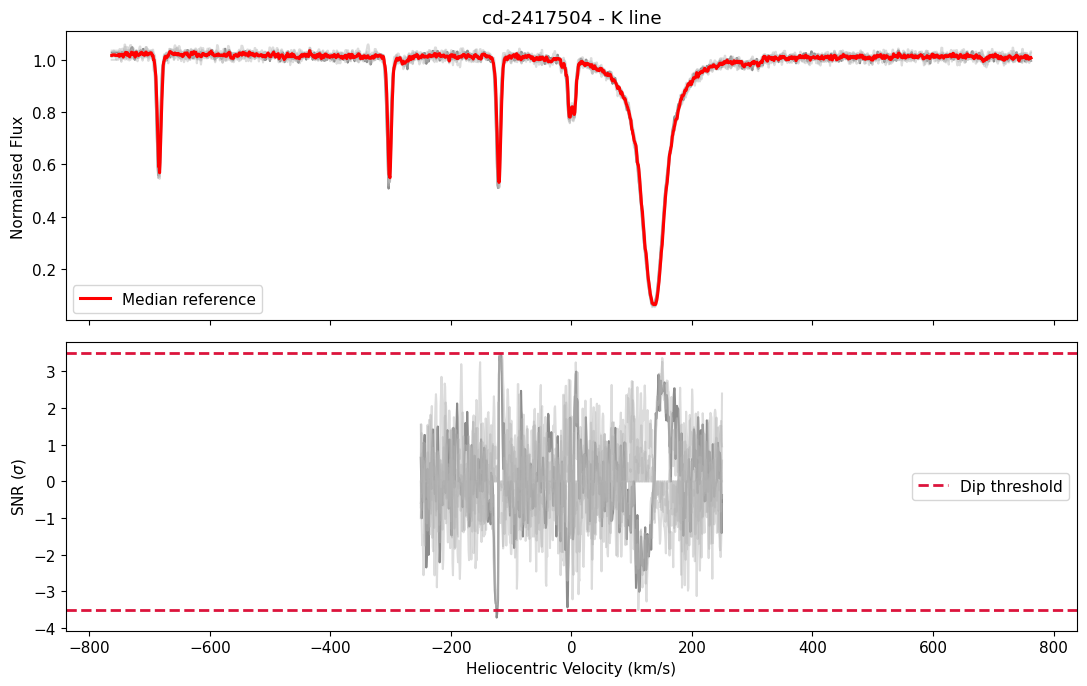


cd-2417504 - H line summary
 epoch  min_sigma  max_sigma  rv_at_min  width  abs_depth
     1      -3.21       3.19     126.69      0      0.256
     2      -2.90       2.79     124.42      0      0.197
     3      -3.08       2.70     124.42      0      0.186
     4      -2.85       2.68       5.67      0      0.057
     5      -2.56       3.02    -209.13      0      0.031
     6      -2.88       2.73    -126.69      0      0.044
     7      -2.60       2.91       9.45      0      0.031
Threshold dip present: False
Peak above +threshold present: False
Dip repeated in multiple epochs: False


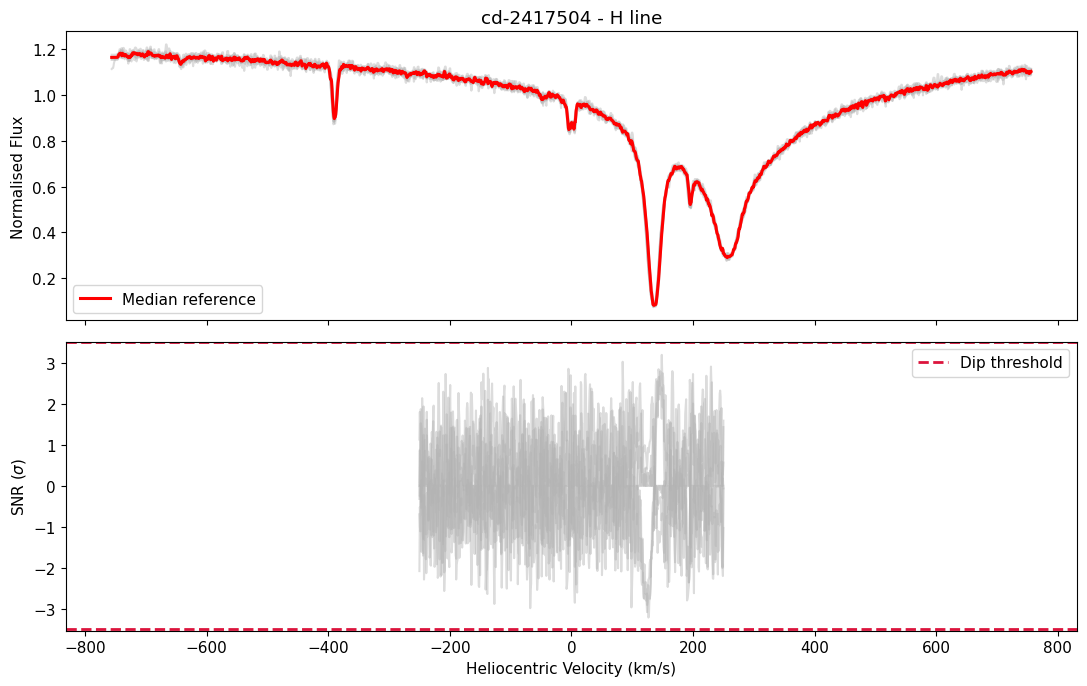

Interpretation guide: an exocomet-like event is usually narrow, redshifted, and transient; a broad dip near the stellar velocity or recurring across epochs is less convincing.


In [4]:
# One-off diagnostic for cd-2417504 without changing the main pipeline.
target_name = 'cd-2417504'
star_path = param['dataset'] + '{}/'.format(target_name)

def inspect_line(line_label):
    local_search = ASSET(parameters=param, line=line_label)
    spec_param = local_search.spec_analysis(star_path)
    if spec_param is None:
        print(f'{target_name} ({line_label}): not enough spectra for inspection.')
        return None

    new_spectra, med, med_err = spec_param
    ref_spec = med[local_search.snr_idxrange]
    summary_rows = []

    for epoch_idx, spec in enumerate(new_spectra):
        filtered_spec = spec[local_search.snr_idxrange]
        snr = local_search.snr(spec, med, local_search.spectra_err[epoch_idx], med_err)
        sd = np.std(snr)
        sig = snr[local_search.snr_idxrange] / sd
        min_detect = float(np.nanmin(sig))
        max_detect = float(np.nanmax(sig))
        filtered_rv = local_search.radial_velocity[local_search.snr_idxrange]
        rv_detect = float(filtered_rv[sig == min_detect][0])
        width = int(local_search.get_width(sig)) if min_detect < local_search.threshold else 0
        abs_depth = float(((ref_spec[filtered_rv == rv_detect] - filtered_spec[filtered_rv == rv_detect]) / ref_spec[filtered_rv == rv_detect])[0])
        summary_rows.append({
            'epoch': epoch_idx + 1,
            'min_sigma': round(min_detect, 2),
            'max_sigma': round(max_detect, 2),
            'rv_at_min': round(rv_detect, 2),
            'width': width,
            'abs_depth': round(abs_depth, 3),
        })

    summary = pd.DataFrame(summary_rows)
    print(f'\n{target_name} - {line_label} line summary')
    print(summary.to_string(index=False))

    has_dip = (summary['min_sigma'] < float(param['threshold'])).any()
    has_peak = (summary['max_sigma'] >= abs(float(param['threshold']))).any()
    repeat_dip = (summary['min_sigma'] < float(param['threshold'])).sum() >= 2

    print('Threshold dip present:', bool(has_dip))
    print('Peak above +threshold present:', bool(has_peak))
    print('Dip repeated in multiple epochs:', bool(repeat_dip))

    fig, (ax_spec, ax_snr) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
    for epoch_idx, spec in enumerate(new_spectra):
        snr = local_search.snr(spec, med, local_search.spectra_err[epoch_idx], med_err)
        sd = np.std(snr)
        sig = snr[local_search.snr_idxrange] / sd
        filtered_rv = local_search.radial_velocity[local_search.snr_idxrange]
        color = 'k' if summary.loc[epoch_idx, 'min_sigma'] < float(param['threshold']) else '0.7'
        ax_spec.plot(local_search.radial_velocity, spec, color=color, alpha=0.45)
        ax_snr.plot(filtered_rv, sig, color=color, alpha=0.45)

    ax_spec.plot(local_search.radial_velocity, med, color='red', linewidth=2.2, label='Median reference')
    ax_spec.set_ylabel('Normalised Flux')
    ax_spec.set_title(f'{target_name} - {line_label} line')
    ax_spec.legend(loc='best')

    ax_snr.axhline(float(param['threshold']), color='crimson', linestyle='--', linewidth=2, label='Dip threshold')
    ax_snr.axhline(abs(float(param['threshold'])), color='crimson', linestyle='--', linewidth=2)
    ax_snr.set_ylabel('SNR ($\sigma$)')
    ax_snr.set_xlabel('Heliocentric Velocity (km/s)')
    ax_snr.legend(loc='best')
    plt.tight_layout()
    plt.show()

    return summary

k_summary = inspect_line('K')
h_summary = inspect_line('H')

print('Interpretation guide: an exocomet-like event is usually narrow, redshifted, and transient; a broad dip near the stellar velocity or recurring across epochs is less convincing.')

In [14]:
def plot_four_stars_side_by_side(star_names, line='K', save_path=None, panel_type_labels=None):
    """Plot the compact iPlotter view for exactly four stars in a 2x2 grid and optionally save."""
    _ensure_runtime_state()

    if isinstance(star_names, str):
        raise ValueError("Provide a list or tuple of exactly four star names.")

    star_names = list(star_names)
    if len(star_names) != 4:
        raise ValueError("This helper expects exactly four stars.")

    if panel_type_labels is None:
        panel_type_labels = ['G-type', 'F-type', 'G-type', 'K-type']
    else:
        panel_type_labels = list(panel_type_labels)

    if len(panel_type_labels) != 4:
        raise ValueError("Provide exactly four panel type labels.")

    save_dir = _get_save_dir()
    os.makedirs(save_dir, exist_ok=True)

    def _resolve_target_row(star_name):
        reduced_name = str(star_name)
        if 'to_reduce' in globals():
            try:
                reduced_name = to_reduce(str(star_name))
            except Exception:
                pass

        candidate_paths = [
            '/home/msp25gd/Downloads/res/meta/metadata.pkl',
            os.path.join(os.getcwd(), 'metadata.pkl'),
            os.path.join(os.getcwd(), 'res', 'meta', 'metadata.pkl'),
        ]
        for metadata_path in candidate_paths:
            if os.path.exists(metadata_path):
                metadata = pd.read_pickle(metadata_path)
                break
        else:
            raise FileNotFoundError('Could not find the metadata pickle for the target helper.')

        reduced_key = None
        for candidate in ['Reduced', 'reduced']:
            if candidate in metadata.columns:
                reduced_key = candidate
                break

        if reduced_key is None:
            raise KeyError('The metadata pickle does not contain a Reduced column.')

        matches = metadata[metadata[reduced_key].astype(str).str.lower() == reduced_name.lower()]
        if len(matches) == 0:
            raise FileNotFoundError(f'Could not find a metadata row for {reduced_name}.')
        return matches.iloc[0]

    fig, axes = plt.subplots(
        4,
        2,
        figsize=(16, 14),
        sharex='col',
        gridspec_kw={'height_ratios': [2, 1, 2, 1]},
        constrained_layout=True,
    )
    fig.suptitle('B-Type Stars Comparison', fontsize=16)

    legend_handles = None
    flux_axes = []

    for star_idx, star_name in enumerate(star_names):
        cand_info = _resolve_target_row(star_name)

        star_red = str(cand_info.get('Reduced', cand_info.get('reduced', str(star_name))))
        star_san = str(cand_info.get('Sanitised', cand_info.get('sanitised', star_red)))
        star_harps = cand_info.get('HARPS', cand_info.get('Harps', cand_info.get('HARP', None)))
        if star_harps is None:
            star_harps = star_red

        search = ASSET(parameters=param, line=line)
        search.target_san = star_san
        search.target_red = star_red
        search.target_harps = star_harps

        star_path = param['dataset'] + '{}/'.format(star_red)
        spec_param = search.spec_analysis(star_path)
        if spec_param is None:
            raise ValueError(f'Not enough spectra for {star_red}.')

        new_spectra, med, med_err = spec_param
        corr_med = med.copy()
        rv_mask = None
        if search.ccf:
            rv_shift = search.X_corr(corr_med)
            rv_mask = (search.radial_velocity > rv_shift - 50) & (search.radial_velocity < rv_shift + 50)
            corr_med[rv_mask] = np.nan

        panel_row = (star_idx // 2) * 2
        panel_col = star_idx % 2
        ax_flux = axes[panel_row, panel_col]
        ax_snr = axes[panel_row + 1, panel_col]
        flux_axes.append(ax_flux)

        ax_flux.set_title(f"{star_san} ({panel_type_labels[star_idx]})")
        ax_flux.set_xlim(search.rv_min, search.rv_max)
        ax_snr.tick_params(axis='x', labelbottom=True)
        ax_snr.hlines(-1 * search.threshold, search.rv_min, search.rv_max, linestyles='dashed', linewidth=3, colors='red')
        ax_snr.hlines(1 * search.threshold, search.rv_min, search.rv_max, linestyles='dashed', linewidth=3, colors='red')

        for epoch_idx, spec in enumerate(new_spectra):
            snr = search.snr(spec, med, search.spectra_err[epoch_idx], med_err)
            sd = np.std(snr)
            corr_snr = snr.copy()[search.snr_idxrange]
            filtered_rv = search.radial_velocity[search.snr_idxrange]

            if search.ccf and rv_mask is not None:
                corr_snr[rv_mask[search.snr_idxrange]] = np.nan

            sig = corr_snr / sd
            min_detect = float(np.nanmin(sig))

            corr_spec = spec.copy()
            if search.ccf and rv_mask is not None:
                corr_spec[rv_mask] = np.nan

            is_detection = False
            if min_detect < search.threshold:
                width = int(search.get_width(sig)) if np.isfinite(sig).any() else 0
                is_detection = width >= search.width_filter

            if is_detection:
                ax_flux.plot(search.radial_velocity, corr_spec, linewidth=2, alpha=0.7, color='k', zorder=5)
                ax_snr.plot(filtered_rv, sig, linewidth=1.5, color='k', alpha=0.5, zorder=5)
            else:
                ax_flux.plot(search.radial_velocity, corr_spec, linewidth=2, alpha=0.2, color='grey', zorder=0)
                ax_snr.plot(filtered_rv, sig, linewidth=1, color='grey', alpha=0.3, zorder=0)

        ax_flux.plot(search.radial_velocity, corr_med, linewidth=2.5, color='r', label='Median Reference', zorder=10)
        if search.ccf:
            ax_flux.plot(search.radial_velocity, med, linewidth=2.5, color='r', linestyle='--', alpha=0.2, label='Original Median Reference', zorder=0)

        if legend_handles is None:
            legend_handles, _ = ax_flux.get_legend_handles_labels()

        if panel_col == 0:
            ax_flux.set_ylabel('Normalised Flux')
            ax_snr.set_ylabel('SNR ($\\sigma$)')
        ax_snr.set_xlabel('Heliocentric Velocity (km/s)')

    if legend_handles is not None:
        spectra_legend = Line2D([0], [0], label='Superimposed spectra', color='g', alpha=0.2)
        spectra_det_legend = Line2D([0], [0], label='Spectra with detection', color='k')
        combined_handles = legend_handles + [spectra_legend, spectra_det_legend]
        combined_labels = [handle.get_label() for handle in combined_handles]
        for ax_flux in flux_axes:
            ax_flux.legend(combined_handles, combined_labels, loc='lower right', fontsize=9)

    plt.show()

    save_choice = input("Save this four-star comparison? (y/n): ").strip().lower()
    if save_choice == 'y':
        if save_path is None:
            joined_names = '_'.join(''.join(ch if ch.isalnum() or ch in '._-' else '_' for ch in str(name)) for name in star_names)
            save_path = os.path.join(save_dir, f'{joined_names}_{line.upper()}_comparison.png')
        fig.savefig(save_path, bbox_inches='tight', dpi=150)
        print(f'Saved figure to {save_path}')
    elif save_choice == 'n':
        print('Figure not saved.')
    else:
        print('Input not recognised. Figure not saved.')

    return fig


# Example usage:
# stars_to_compare = ['betpic', 'hd39060', '51oph', 'hd60753']
# type_labels = ['G-type', 'F-type', 'G-type', 'K-type']
# plot_four_stars_side_by_side(stars_to_compare, line='K', panel_type_labels=type_labels)

In [10]:
# Bootstrap helpers if this notebook section is run out of order.
if 'np' not in globals():
    import numpy as np
if 'pd' not in globals():
    import pandas as pd
if 'plt' not in globals():
    import matplotlib.pyplot as plt

if '_ensure_runtime_state' not in globals():
    from IPython import get_ipython
    import os
    import json

    def _ensure_runtime_state():
        if 'param' not in globals():
            candidate_param_paths = [
                'param.json',
                os.path.join(os.getcwd(), 'param.json'),
                os.path.join('/home/msp25gd/ResearchProjectMSc/HR/search', 'param.json'),
            ]
            for param_path in candidate_param_paths:
                if os.path.exists(param_path):
                    with open(param_path) as paramfile:
                        globals()['param'] = json.load(paramfile)
                    break

        ip = get_ipython()
        if ip is not None:
            for notebook_name in ['asset.ipynb', 'reduce_name.ipynb']:
                notebook_path = os.path.join('/home/msp25gd/ResearchProjectMSc/HR/search', notebook_name)
                if os.path.exists(notebook_path):
                    try:
                        ip.run_line_magic('run', notebook_path)
                    except Exception:
                        pass

        missing = [name for name in ['ASSET', 'to_reduce', 'param'] if name not in globals()]
        if missing:
            raise RuntimeError(
                f"Runtime not initialised. Missing: {missing}. "
                "Run the setup cells in HR/search/iplotter.ipynb from top to bottom."
            )

if '_get_save_dir' not in globals():
    import os

    def _get_save_dir():
        for candidate_root in [
            os.getcwd(),
            os.path.dirname(os.getcwd()),
            os.path.abspath(os.path.join(os.getcwd(), '..', '..')),
        ]:
            if os.path.isdir(os.path.join(candidate_root, 'Images')):
                return os.path.join(candidate_root, 'Images', 'finalStarImages')
        return os.path.join(os.getcwd(), 'Images', 'finalStarImages')

if 'Line2D' not in globals():
    from matplotlib.lines import Line2D

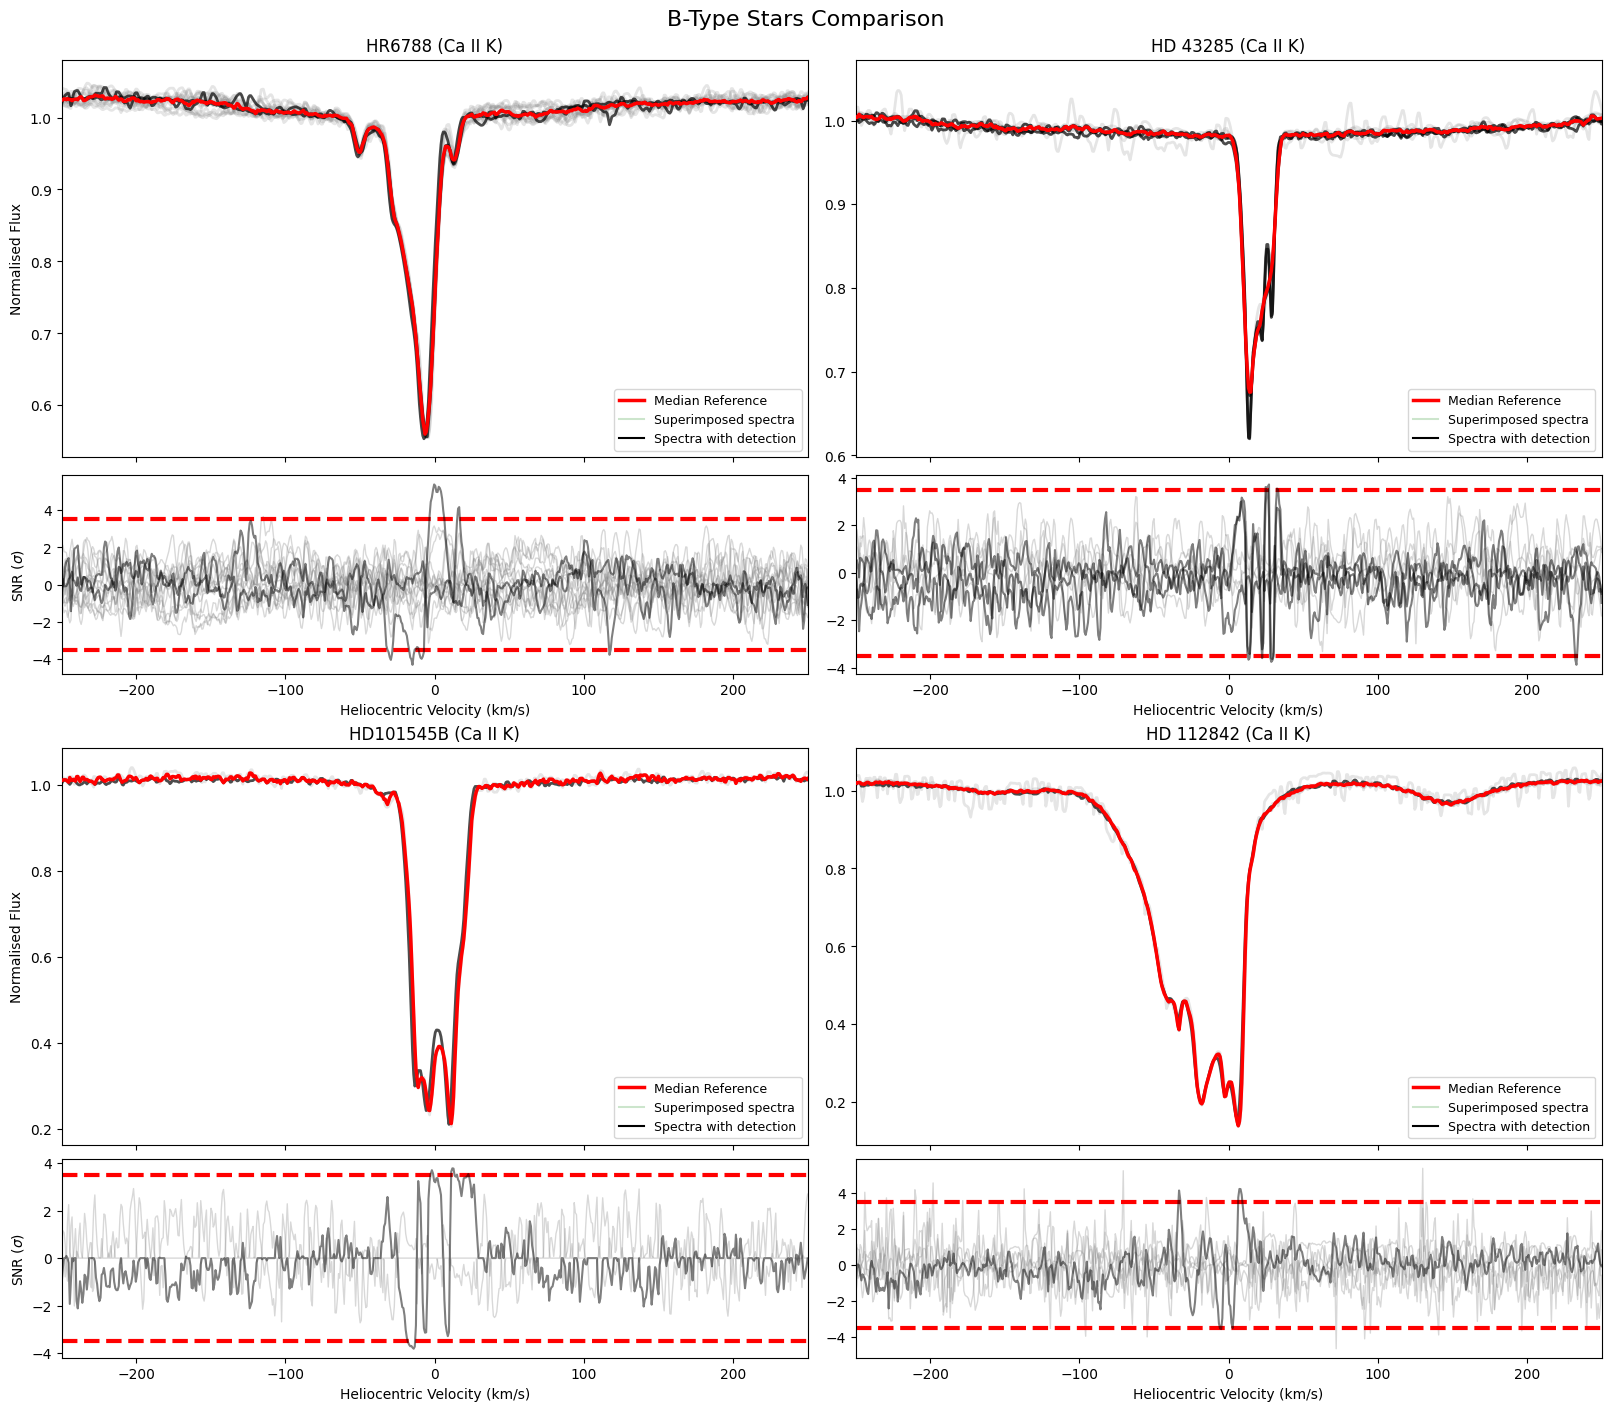

Saved figure to /home/msp25gd/ResearchProjectMSc/Images/finalStarImages/hr6788_hd43285_hd101545b_hd112842_K_comparison.png


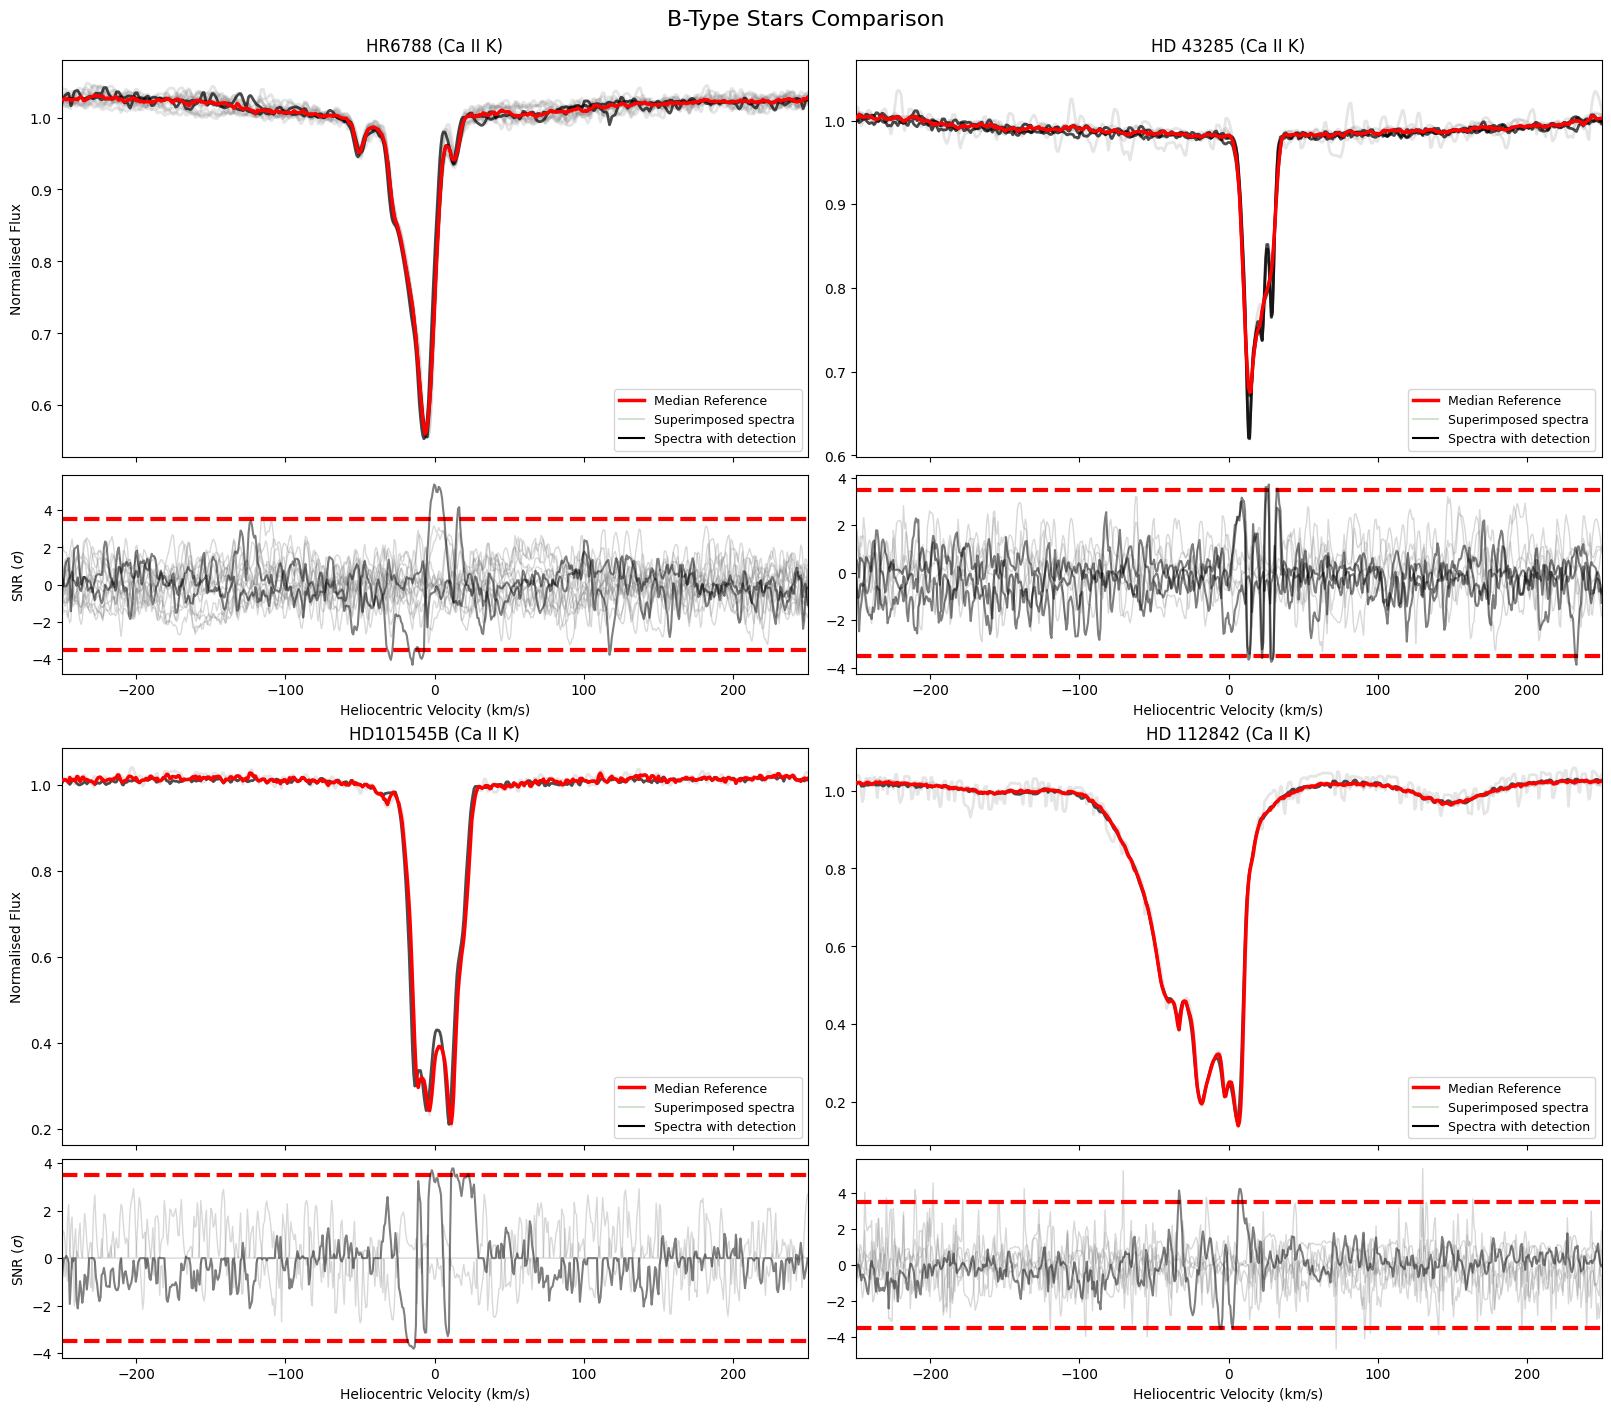

In [15]:
stars_to_compare = ['hr6788', 'hd43285', 'hd101545b', 'hd112842']
type_labels = ['Ca II K', 'Ca II K', 'Ca II K', 'Ca II K']
plot_four_stars_side_by_side(stars_to_compare, line='K', panel_type_labels=type_labels)

In [42]:
print('All stars have been looked at.')

All stars have been looked at.


In [58]:
from pathlib import Path
import numpy as np
import pandas as pd

base = Path('/home/msp25gd/Downloads/res/dataset')
for name in ['betpic', 'hd39060']:
    p = base / name
    df = pd.read_pickle(p / 'meta' / 'group_df.pkl')
    fits = np.load(p / 'meta' / 'fits.npy', allow_pickle=True)
    sK = np.load(p / 'spec' / 'sK.npy')
    sH = np.load(p / 'spec' / 'sH.npy')
    print(name, 'rows', len(df), 'fits', len(fits), 'sK', sK.shape, 'sH', sH.shape)

print('same rvK', np.array_equal(np.load(base / 'betpic' / 'wavelength' / 'rvK.npy'), np.load(base / 'hd39060' / 'wavelength' / 'rvK.npy')))
print('same rvH', np.array_equal(np.load(base / 'betpic' / 'wavelength' / 'rvH.npy'), np.load(base / 'hd39060' / 'wavelength' / 'rvH.npy')))
print('same wK', np.array_equal(np.load(base / 'betpic' / 'wavelength' / 'wK.npy'), np.load(base / 'hd39060' / 'wavelength' / 'wK.npy')))
print('same wH', np.array_equal(np.load(base / 'betpic' / 'wavelength' / 'wH.npy'), np.load(base / 'hd39060' / 'wavelength' / 'wH.npy')))

merged_df = pd.read_pickle(base / 'hd39060' / 'meta' / 'group_df.pkl')
merged_fits = np.load(base / 'hd39060' / 'meta' / 'fits.npy', allow_pickle=True)
print('merged hd39060 rows', len(merged_df), 'fits', len(merged_fits))

betpic rows 9 fits 9 sK (9, 2000) sH (9, 2000)
hd39060 rows 42 fits 42 sK (42, 2000) sH (42, 2000)
same rvK True
same rvH True
same wK True
same wH True
merged hd39060 rows 42 fits 42


[1/1] hd39060


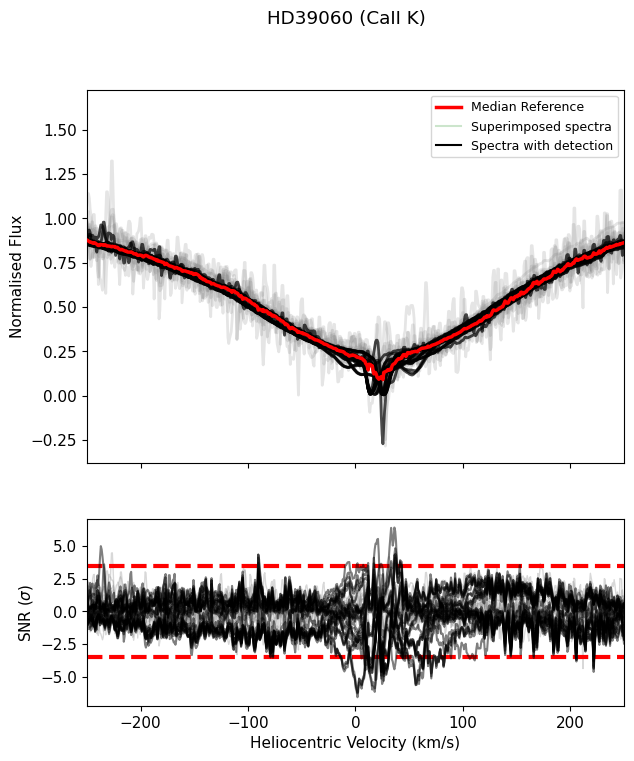

Saved figure to /home/msp25gd/ResearchProjectMSc/Images/starExamples/HD39060_K.png


In [59]:
# Plot the merged hd39060 group through the normal single-star pipeline
plot_single_star_iplotter('hd39060', line='K', save_path=None, show=True)

In [67]:
from PIL import Image
print('HD39060_K.png', Image.open('/home/msp25gd/ResearchProjectMSc/Images/starExamples/HD39060_K.png').size)
print('BPTau_K.png', Image.open('/home/msp25gd/ResearchProjectMSc/Images/starExamples/BPTau_K.png').size)

HD39060_K.png (1040, 1200)
BPTau_K.png (1040, 1142)


[1/2] hd60753


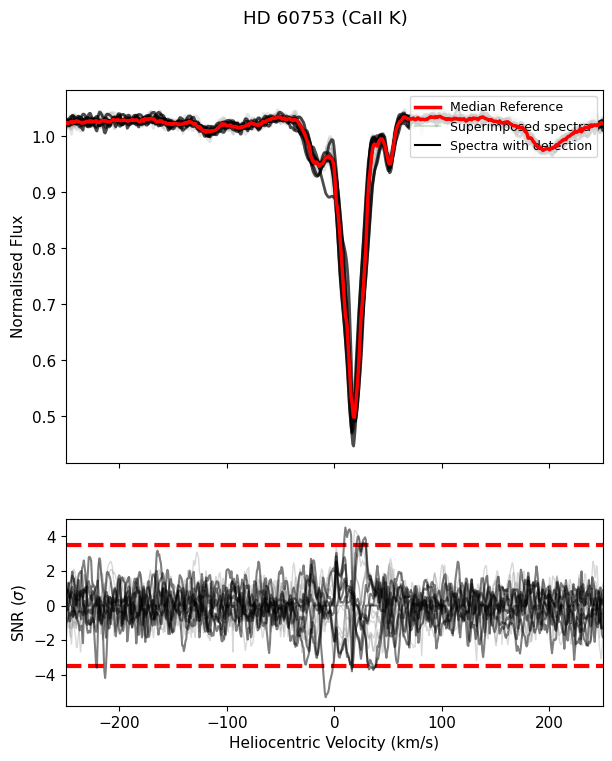

Saved figure to /home/msp25gd/ResearchProjectMSc/Images/finalStarImages/HD_60753_K.png
[2/2] hd10638


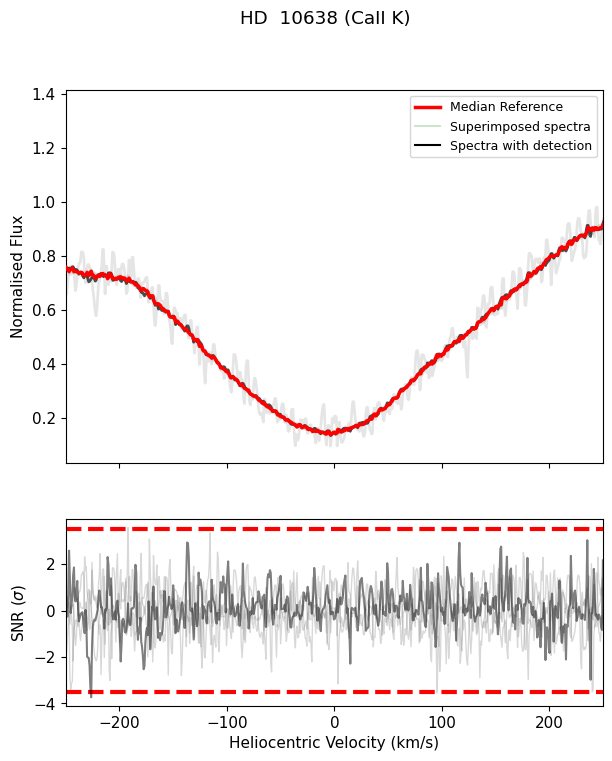

Saved figure to /home/msp25gd/ResearchProjectMSc/Images/finalStarImages/HD__10638_K.png


In [102]:
plot_single_star_iplotter(['hd60753','hd10638'])

In [27]:
from pathlib import Path
print('Active dataset:', param.get('dataset'))
expected = '/home/msp25gd/Downloads/res/dataset/'
print('Using pre-degradation dataset:', param.get('dataset') == expected)
for star in ['hd60753', 'hd10638']:
    star_path = Path(param['dataset']) / star
    print(star, 'exists in dataset:', star_path.exists())

Active dataset: /home/msp25gd/Downloads/res/dataset/
Using pre-degradation dataset: True
hd60753 exists in dataset: True
hd10638 exists in dataset: True


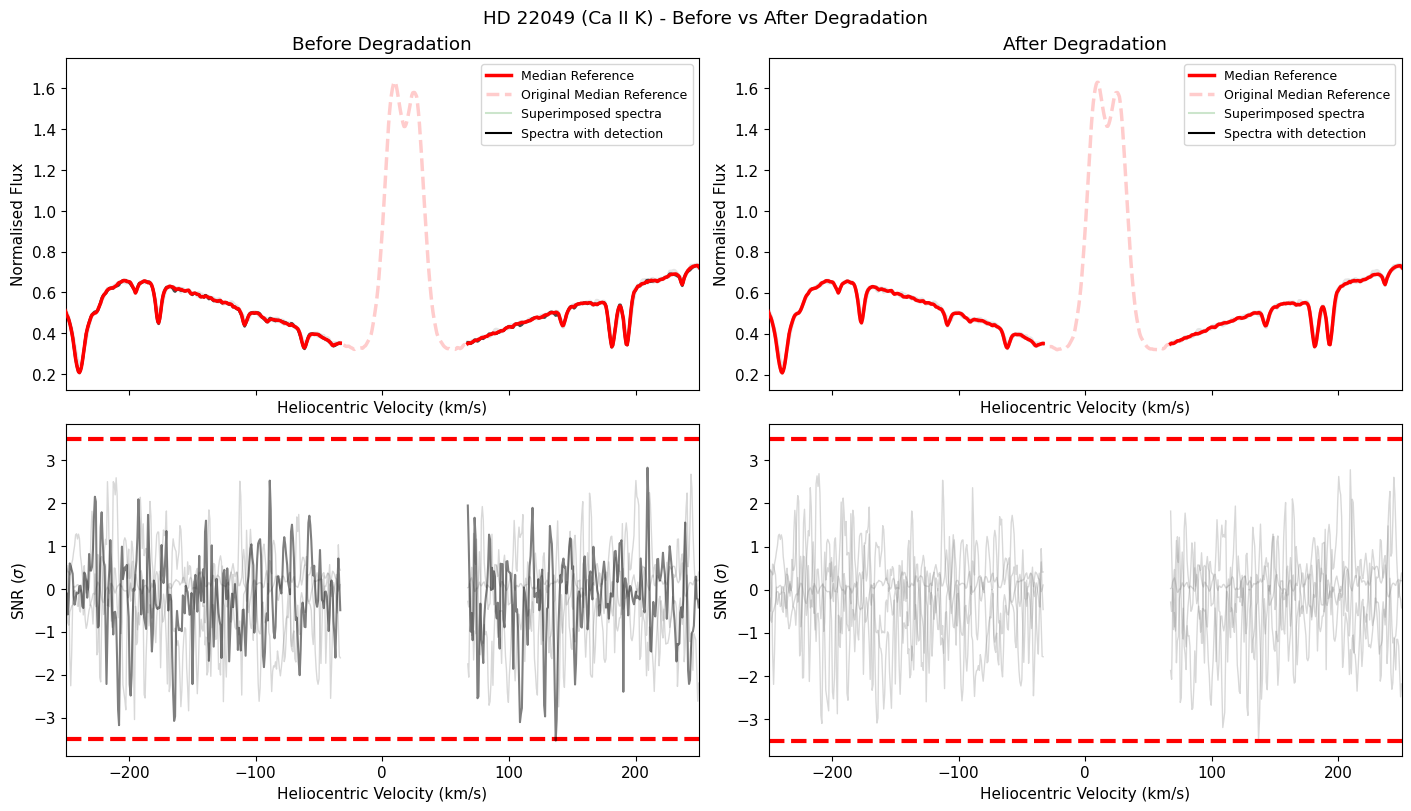

Saved: /home/msp25gd/ResearchProjectMSc/Images/finalStarImages/HD_22049_K_resolution_comparison.png


In [119]:
%run ./resolutionComparison.py

stars_for_comparison = ['hd22049']
if isinstance(starNames, (list, tuple, np.ndarray)) and len(starNames) > 0:
    stars_for_comparison = list(starNames)
elif 'starName' in globals() and starName not in [None, '', 'None']:
    stars_for_comparison = [starName]
else:
    raise ValueError('Set starNames or starName before running resolution comparison.')

plot_resolution_comparison(
    star_names=stars_for_comparison,
    asset_cls=ASSET,
    to_reduce_fn=to_reduce,
    base_param=param,
    line=args.line,
    save=True,
    save_dir=final_save_dir,
    pre_dataset='/home/msp25gd/Downloads/res/dataset/',
    post_dataset='/home/msp25gd/ResearchProjectMSc/ResolutionHandling/processed_candidates/',
)

In [16]:
print("hey")

hey


Target input: hd22049
Reduced target: hd22049
Datasets found: 2
  1. /home/msp25gd/Downloads/res/dataset | folder=hd22049 | source=known-root-direct
  2. /home/msp25gd/ResearchProjectMSc/ResolutionHandling/processed_candidates | folder=hd22049 | source=known-root-direct
[PLOT] dataset=/home/msp25gd/Downloads/res/dataset | folder=hd22049 | epochs=4 | strict detections=0


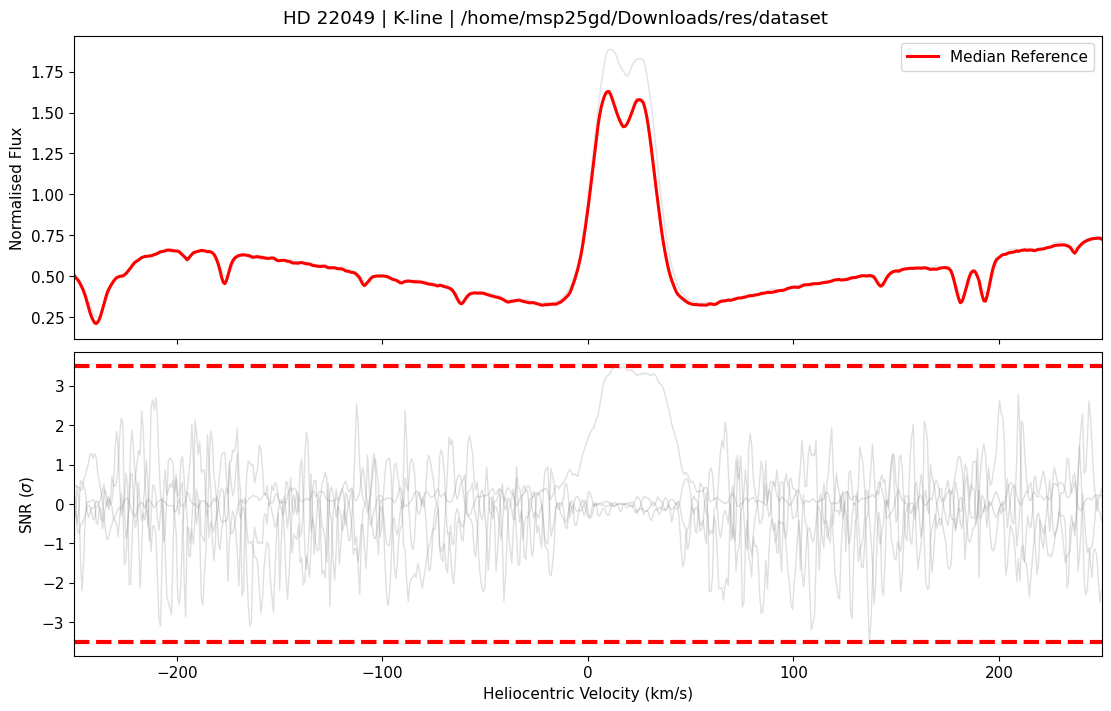

[PLOT] dataset=/home/msp25gd/ResearchProjectMSc/ResolutionHandling/processed_candidates | folder=hd22049 | epochs=4 | strict detections=0


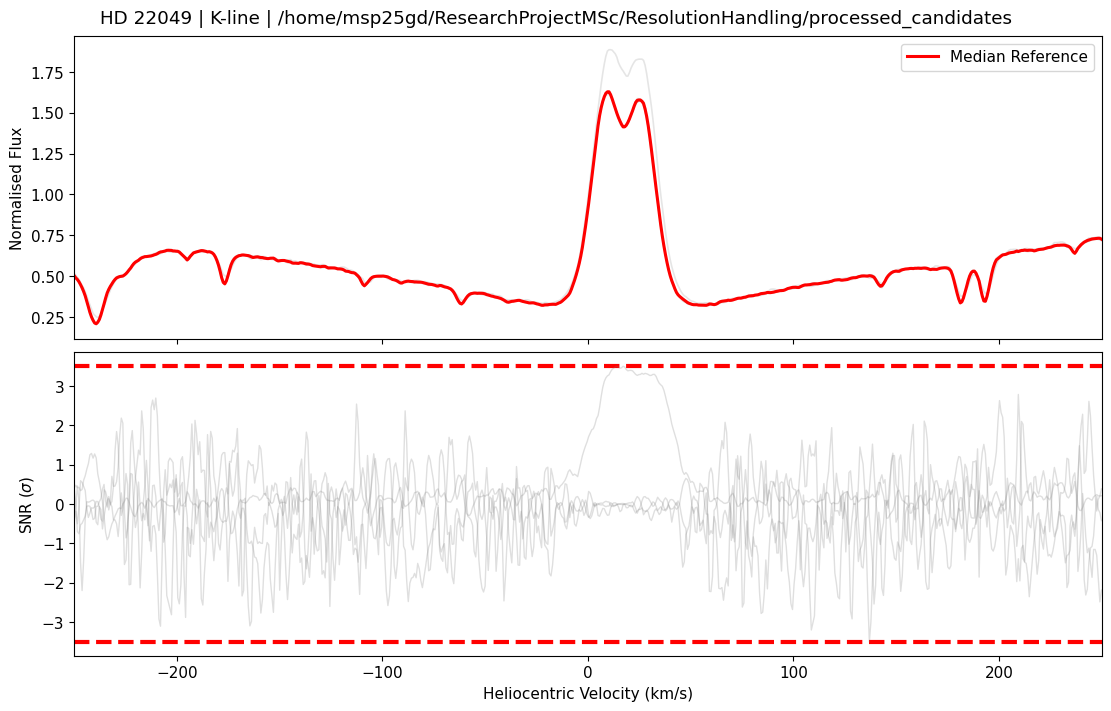

In [29]:
from pathlib import Path
import copy
import numpy as np
import matplotlib.pyplot as plt

# Set this explicitly if needed; otherwise defaults to starNames[0].
TARGET_STAR = globals().get('TARGET_STAR', None)
LINE_TO_PLOT = globals().get('LINE_TO_PLOT', 'K')


def _reduce_name(star_name):
    if 'to_reduce' in globals():
        try:
            return str(to_reduce(str(star_name)))
        except Exception:
            return str(star_name)
    return str(star_name)


def find_all_star_datasets(star_name):
    reduced = _reduce_name(star_name)

    known_roots = [
        Path('/home/msp25gd/Downloads/res/dataset'),
        Path('/home/msp25gd/ResearchProjectMSc/ResolutionHandling/processed_candidates'),
        Path('/home/msp25gd/ResearchProjectMSc/np'),
    ]

    found = []
    seen = set()

    def _add(dataset_root, star_folder, origin):
        key = (str(dataset_root), str(star_folder))
        if key in seen:
            return
        seen.add(key)
        found.append(
            {
                'dataset_root': str(dataset_root),
                'star_folder': str(star_folder),
                'origin': origin,
            }
        )

    # Fast known-root checks.
    for root in known_roots:
        if not root.exists() or not root.is_dir():
            continue

        direct = root / reduced
        if (direct / 'meta' / 'group_df.pkl').exists():
            _add(root, direct.name, 'known-root-direct')
            continue

        # Case-insensitive fallback in each known root.
        for child in root.iterdir():
            if not child.is_dir():
                continue
            if child.name.lower() == reduced.lower() and (child / 'meta' / 'group_df.pkl').exists():
                _add(root, child.name, 'known-root-case-insensitive')

    # Broader search under likely parent trees.
    broad_search_roots = [
        Path('/home/msp25gd/Downloads'),
        Path('/home/msp25gd/ResearchProjectMSc'),
    ]
    pattern = f'**/{reduced}/meta/group_df.pkl'

    for base in broad_search_roots:
        if not base.exists() or not base.is_dir():
            continue
        for hit in base.glob(pattern):
            # .../<dataset_root>/<star_folder>/meta/group_df.pkl
            star_folder = hit.parents[1].name
            dataset_root = hit.parents[2]
            _add(dataset_root, star_folder, 'broad-search')

    return reduced, found


def plot_star_from_dataset(dataset_root, star_folder, line='K'):
    local_param = copy.deepcopy(param)
    local_param['dataset'] = str(dataset_root) + '/'

    search = ASSET(parameters=local_param, line=line)
    search.ccf = False

    star_path = local_param['dataset'] + f'{star_folder}/'
    spec_param = search.spec_analysis(star_path)
    if spec_param is None:
        print(f'[SKIP] {star_folder} in {dataset_root}: not enough spectra')
        return

    new_spectra, med, med_err = spec_param
    corr_med = med.copy()

    fig, (ax_flux, ax_snr) = plt.subplots(2, 1, figsize=(11, 7), sharex=True, constrained_layout=True)
    fig.suptitle(f"{search.target_san} | {line}-line | {dataset_root}")

    ax_flux.set_ylabel('Normalised Flux')
    ax_flux.set_xlim(search.rv_min, search.rv_max)

    ax_snr.set_ylabel('SNR ($\\sigma$)')
    ax_snr.set_xlabel('Heliocentric Velocity (km/s)')
    ax_snr.hlines(-1 * search.threshold, search.rv_min, search.rv_max, linestyles='dashed', linewidth=3, colors='red')
    ax_snr.hlines(1 * search.threshold, search.rv_min, search.rv_max, linestyles='dashed', linewidth=3, colors='red')

    det_count = 0
    for i, spec in enumerate(new_spectra):
        snr = search.snr(spec, med, search.spectra_err[i], med_err)
        sd = np.std(snr)
        sig = snr[search.snr_idxrange] / sd
        filtered_rv = search.radial_velocity[search.snr_idxrange]

        min_detect = np.nanmin(sig)
        is_detection = False
        if min_detect < search.threshold:
            width = search.get_width(sig)
            is_detection = width >= search.width_filter

        if is_detection:
            det_count += 1
            ax_flux.plot(search.radial_velocity, spec, linewidth=1.8, alpha=0.7, color='k')
            ax_snr.plot(filtered_rv, sig, linewidth=1.3, alpha=0.6, color='k')
        else:
            ax_flux.plot(search.radial_velocity, spec, linewidth=1.2, alpha=0.2, color='grey')
            ax_snr.plot(filtered_rv, sig, linewidth=1.0, alpha=0.25, color='grey')

    ax_flux.plot(search.radial_velocity, corr_med, linewidth=2.2, color='red', label='Median Reference')
    ax_flux.legend(loc='best')

    print(f"[PLOT] dataset={dataset_root} | folder={star_folder} | epochs={len(new_spectra)} | strict detections={det_count}")
    plt.show()


if TARGET_STAR is None:
    if 'starNames' in globals() and isinstance(starNames, (list, tuple, np.ndarray)) and len(starNames) > 0:
        TARGET_STAR = starNames[0]
    elif 'args' in globals() and getattr(args, 'star', 'None') not in ['None', None, '']:
        TARGET_STAR = args.star
    elif 'target_name' in globals():
        TARGET_STAR = target_name
    else:
        raise ValueError('Set TARGET_STAR before running this cell.')

reduced_target, matches = find_all_star_datasets(TARGET_STAR)
print(f'Target input: {TARGET_STAR}')
print(f'Reduced target: {reduced_target}')
print(f'Datasets found: {len(matches)}')
for idx, row in enumerate(matches, 1):
    print(f"  {idx}. {row['dataset_root']} | folder={row['star_folder']} | source={row['origin']}")

if len(matches) == 0:
    raise FileNotFoundError(f'No dataset roots found that contain {reduced_target}.')

for row in matches:
    plot_star_from_dataset(Path(row['dataset_root']), row['star_folder'], line=LINE_TO_PLOT)


Target input: hd22049
Reduced target: hd22049
Metadata-matched folders: 2
  1. /home/msp25gd/Downloads/res/dataset/hd22049
  2. /home/msp25gd/ResearchProjectMSc/ResolutionHandling/processed_candidates/hd22049

--- Plotting line H ---
[PLOT] /home/msp25gd/Downloads/res/dataset/hd22049 (H) | epochs=4 | strict detections=1


Target input: hd22049
Reduced target: hd22049
Metadata-matched folders: 2
  1. /home/msp25gd/Downloads/res/dataset/hd22049
  2. /home/msp25gd/ResearchProjectMSc/ResolutionHandling/processed_candidates/hd22049

--- Plotting line H ---
[PLOT] /home/msp25gd/Downloads/res/dataset/hd22049 (H) | epochs=4 | strict detections=1


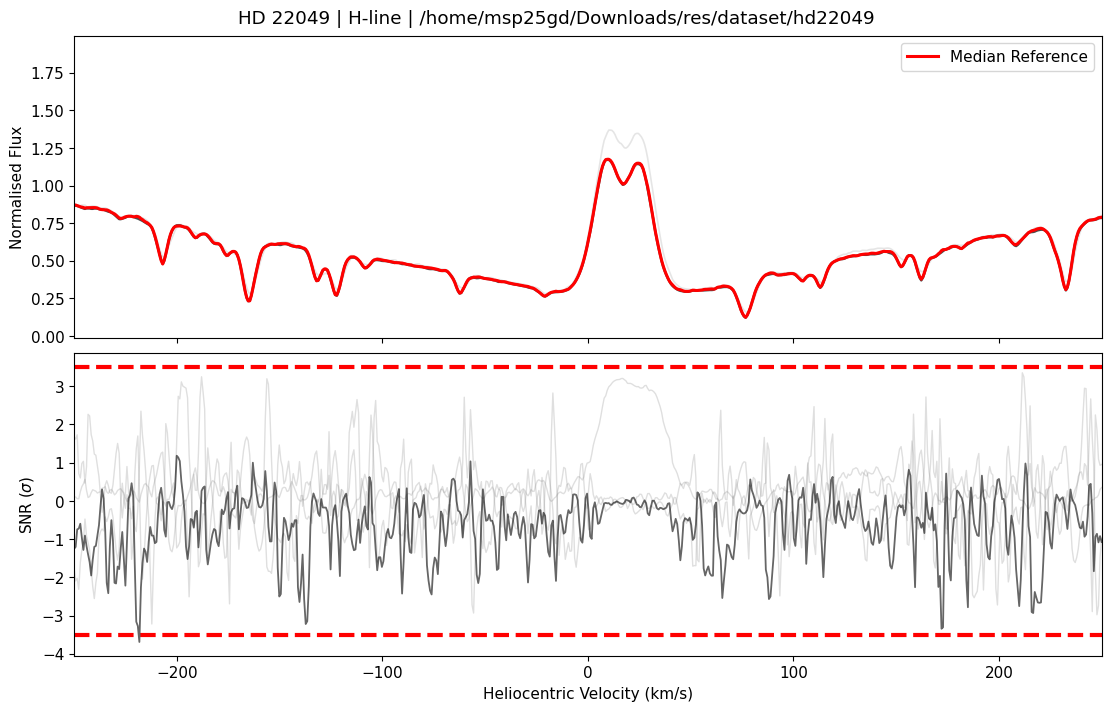

Target input: hd22049
Reduced target: hd22049
Metadata-matched folders: 2
  1. /home/msp25gd/Downloads/res/dataset/hd22049
  2. /home/msp25gd/ResearchProjectMSc/ResolutionHandling/processed_candidates/hd22049

--- Plotting line H ---
[PLOT] /home/msp25gd/Downloads/res/dataset/hd22049 (H) | epochs=4 | strict detections=1


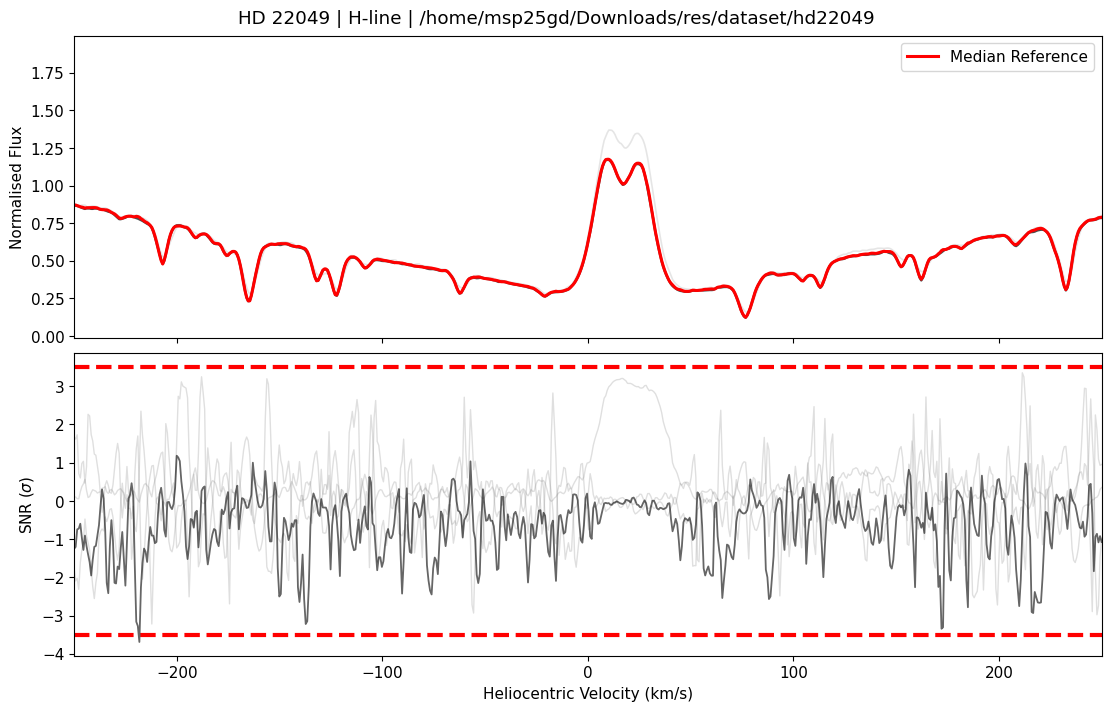

[PLOT] /home/msp25gd/ResearchProjectMSc/ResolutionHandling/processed_candidates/hd22049 (H) | epochs=4 | strict detections=1


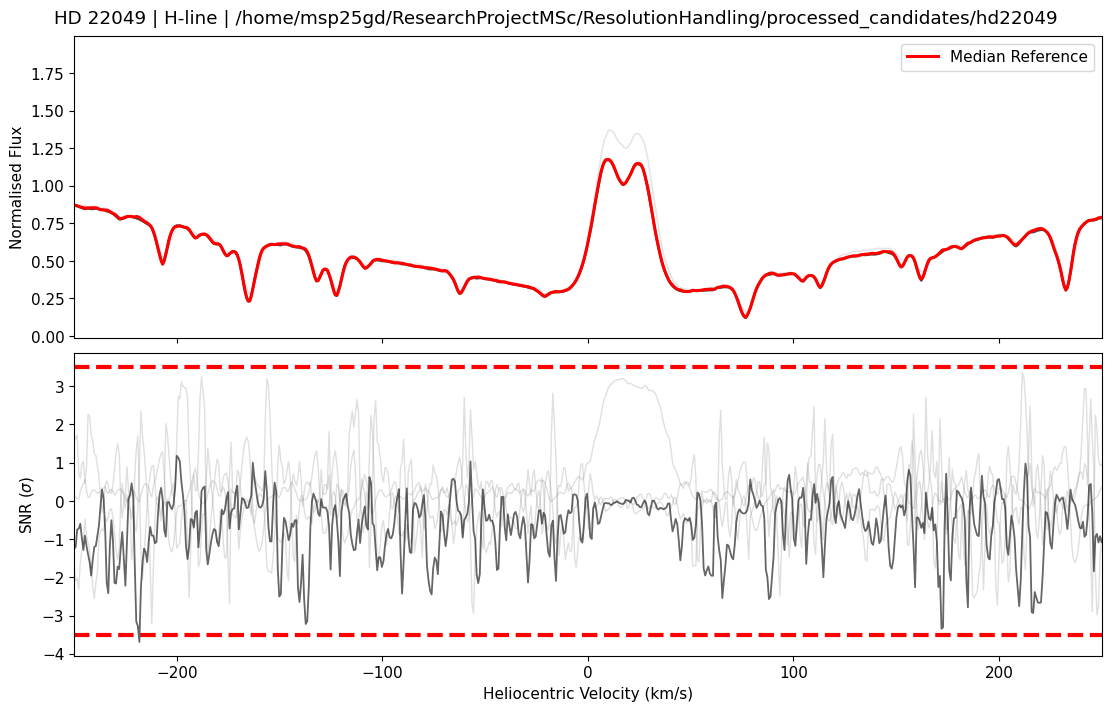

In [33]:
from pathlib import Path
import pandas as pd
import copy
import numpy as np
import matplotlib.pyplot as plt

TARGET_STAR = globals().get('TARGET_STAR', 'hd22049')
LINES_TO_CHECK = globals().get('LINES_TO_CHECK', ['K'])


def _reduced_target_name(name):
    if 'to_reduce' in globals():
        try:
            return str(to_reduce(str(name)))
        except Exception:
            return str(name)
    return str(name)


def _find_star_folders_by_metadata(dataset_root, reduced_target):
    hits = []
    if not dataset_root.exists() or not dataset_root.is_dir():
        return hits

    for child in dataset_root.iterdir():
        if not child.is_dir():
            continue
        meta_file = child / 'meta' / 'group_df.pkl'
        if not meta_file.exists():
            continue

        try:
            df = pd.read_pickle(meta_file)
        except Exception:
            continue

        reduced_cols = [c for c in ['Reduced', 'reduced'] if c in df.columns]
        if not reduced_cols:
            continue

        found = False
        for col in reduced_cols:
            col_values = df[col].astype(str).str.lower()
            if (col_values == reduced_target.lower()).any():
                found = True
                break

        if found:
            hits.append(child.name)

    return sorted(set(hits))


def _plot_dataset_folder(dataset_root, folder_name, line='K'):
    local_param = copy.deepcopy(param)
    local_param['dataset'] = str(dataset_root) + '/'
    search = ASSET(parameters=local_param, line=line)
    search.ccf = False

    star_path = local_param['dataset'] + f'{folder_name}/'
    spec_param = search.spec_analysis(star_path)
    if spec_param is None:
        print(f'[SKIP] {dataset_root}/{folder_name} ({line}): not enough spectra')
        return

    new_spectra, med, med_err = spec_param

    fig, (ax_flux, ax_snr) = plt.subplots(2, 1, figsize=(11, 7), sharex=True, constrained_layout=True)
    fig.suptitle(f"{search.target_san} | {line}-line | {dataset_root}/{folder_name}")

    ax_flux.set_ylabel('Normalised Flux')
    ax_flux.set_xlim(search.rv_min, search.rv_max)

    ax_snr.set_ylabel('SNR ($\\sigma$)')
    ax_snr.set_xlabel('Heliocentric Velocity (km/s)')
    ax_snr.hlines(-1 * search.threshold, search.rv_min, search.rv_max, linestyles='dashed', linewidth=3, colors='red')
    ax_snr.hlines(1 * search.threshold, search.rv_min, search.rv_max, linestyles='dashed', linewidth=3, colors='red')

    det_count = 0
    for i, spec in enumerate(new_spectra):
        snr = search.snr(spec, med, search.spectra_err[i], med_err)
        sd = np.std(snr)
        sig = snr[search.snr_idxrange] / sd
        filtered_rv = search.radial_velocity[search.snr_idxrange]

        min_detect = np.nanmin(sig)
        is_detection = False
        if min_detect < search.threshold:
            width = search.get_width(sig)
            is_detection = width >= search.width_filter

        if is_detection:
            det_count += 1
            ax_flux.plot(search.radial_velocity, spec, linewidth=1.8, alpha=0.7, color='k')
            ax_snr.plot(filtered_rv, sig, linewidth=1.3, alpha=0.6, color='k')
        else:
            ax_flux.plot(search.radial_velocity, spec, linewidth=1.2, alpha=0.2, color='grey')
            ax_snr.plot(filtered_rv, sig, linewidth=1.0, alpha=0.25, color='grey')

    ax_flux.plot(search.radial_velocity, med, linewidth=2.2, color='red', label='Median Reference')
    ax_flux.legend(loc='best')

    print(f'[PLOT] {dataset_root}/{folder_name} ({line}) | epochs={len(new_spectra)} | strict detections={det_count}')
    plt.show()


reduced_target = _reduced_target_name(TARGET_STAR)
roots = [
    Path('/home/msp25gd/Downloads/res/dataset'),
    Path('/home/msp25gd/ResearchProjectMSc/ResolutionHandling/processed_candidates'),
]

all_matches = []
for root in roots:
    folders = _find_star_folders_by_metadata(root, reduced_target)
    for folder in folders:
        all_matches.append((root, folder))

# Deduplicate while preserving order.
seen = set()
unique_matches = []
for root, folder in all_matches:
    key = (str(root), str(folder))
    if key in seen:
        continue
    seen.add(key)
    unique_matches.append((root, folder))

print(f'Target input: {TARGET_STAR}')
print(f'Reduced target: {reduced_target}')
print(f'Metadata-matched folders: {len(unique_matches)}')
for i, (root, folder) in enumerate(unique_matches, 1):
    print(f'  {i}. {root}/{folder}')

if len(unique_matches) == 0:
    raise FileNotFoundError(f'No metadata-matched folders found for {reduced_target}.')

for line in LINES_TO_CHECK:
    print(f'\n--- Plotting line {line} ---')
    for root, folder in unique_matches:
        _plot_dataset_folder(root, folder, line=line)
